# Promoter Variant Activity Evaluation

이미 생성된 프로모터 시퀀스(`data/promoters/`)를 AlphaGenome으로 평가하여,  
reference 대비 활성 변화를 masking ratio × model 조합별로 비교합니다.

**워크플로우**
1. **Part 2**: `data/promoters/` 자동 탐색 → CSV 로드 + reference 서열 fetch
2. **Part 3**: AlphaGenome 클라이언트 초기화
3. **Part 4**: CAGE / PROCAP / RNA-SEQ 지표 평가 (모든 조합 × 지정 iteration)
4. **Part 5**: 사용자 지정 iteration의 CAGE 전체 cell ontology 스캔 → 상위 10개 추출
5. **Part 6** *(Optional)*: CHIP-TF 분석 (TF binding site 변화)

In [12]:
# %%capture
%pip -q install biopython alphagenome python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [13]:
import gc
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── Path setup ────────────────────────────────────────────────────────
# utils.py lives in 03_dna-fm-to-alphagenome/
sys.path.append(str(Path('..').resolve()))

from utils import (
    build_transcript_extractors,
    get_dna_model,
    get_output_metadata,
    get_sequence_from_ensembl_region,
    load_gtf_feather,
    normalize_sequence,
    prepare_gtf_views,
    reverse_complement,
)

# ── Gene & Promoter Settings ──────────────────────────────────────────
GENE_NAME = 'GAPDH'
# Promoter window: TSS -250 ~ +50 bp (gen-promoter.ipynb 기준)
PROMOTER_UPSTREAM   = 250        # bp upstream of TSS
PROMOTER_DOWNSTREAM = 50         # bp downstream of TSS
ENSEMBL_SPECIES = 'human'
ENSEMBL_ASSEMBLY = 'GRCh38'

# ── Evaluation Settings ───────────────────────────────────────────────
MODELS_TO_USE = ['DNABERT-2', 'NT-v2-50m', 'NT-v2-500m']
EVAL_ITERATIONS = [0, 10, 20, 30]
REQUESTED_OUTPUT_TYPES = {'CAGE', 'PROCAP', 'RNA_SEQ'}
PROMOTER_PADDING = 500           # Flanking region for analysis / visualization

# Preliminary ontology terms used for Part 4 visualization
# (HeLa: EFO:0002067, erythroblast: CL:0000765)
# Set to None to predict all cell types (slower)
PRELIMINARY_ONTOLOGY_TERMS = ['EFO:0002067', 'CL:0000765']

# ── Data Paths ────────────────────────────────────────────────────────
DATA_DIR = Path('../../data')
PROMOTER_DATA_DIR = DATA_DIR / 'promoters'

print(f'Gene: {GENE_NAME}')
print(f'Promoter window: TSS -{PROMOTER_UPSTREAM} ~ +{PROMOTER_DOWNSTREAM} bp')
print(f'Models: {MODELS_TO_USE}')
print(f'Eval iterations: {EVAL_ITERATIONS}')
print(f'Output types: {REQUESTED_OUTPUT_TYPES}')
print(f'Preliminary ontology terms: {PRELIMINARY_ONTOLOGY_TERMS}')

Gene: GAPDH
Promoter window: TSS -250 ~ +50 bp
Models: ['DNABERT-2', 'NT-v2-50m', 'NT-v2-500m']
Eval iterations: [0, 10, 20, 30]
Output types: {'PROCAP', 'RNA_SEQ', 'CAGE'}
Preliminary ontology terms: ['EFO:0002067', 'CL:0000765']


---
## Part 2: Data Load
### 2-1. Auto-discover conditions from `data/promoters/`

In [14]:
# Auto-discover all (strategy, mask_ratio, model) combinations
# Directory format: sampling_t{T}_mask{M}_iter{N}/{model}/{gene}_promoter.csv
_PATTERN = re.compile(r'^(\w+)_t([\d.]+)_mask([\d.]+)_iter(\d+)$')

conditions = []
for condition_dir in sorted(PROMOTER_DATA_DIR.iterdir()):
    if not condition_dir.is_dir():
        continue
    m = _PATTERN.match(condition_dir.name)
    if not m:
        print(f'Skipping (unrecognized format): {condition_dir.name}')
        continue
    strategy, temp, mask_ratio, n_iter = m.groups()
    strategy_key = f'{strategy}_t{temp}'  # key used as CSV row index

    for model_dir in sorted(condition_dir.iterdir()):
        if not model_dir.is_dir():
            continue
        model_name = model_dir.name
        if model_name not in MODELS_TO_USE:
            continue
        csv_path = model_dir / f'{GENE_NAME}_promoter.csv'
        if not csv_path.exists():
            print(f'  Warning: missing {csv_path}')
            continue
        conditions.append({
            'label': f'mask{mask_ratio}/{model_name}',
            'strategy': strategy,
            'temperature': float(temp),
            'mask_ratio': float(mask_ratio),
            'n_iter': int(n_iter),
            'model': model_name,
            'strategy_key': strategy_key,
            'csv_path': csv_path,
        })

print(f'Found {len(conditions)} conditions:')
for c in conditions:
    print(f"  {c['label']} ({c['n_iter']} iters)  ← {c['csv_path'].name}")

Found 6 conditions:
  mask0.1/DNABERT-2 (30 iters)  ← GAPDH_promoter.csv
  mask0.1/NT-v2-500m (30 iters)  ← GAPDH_promoter.csv
  mask0.1/NT-v2-50m (30 iters)  ← GAPDH_promoter.csv
  mask0.2/DNABERT-2 (30 iters)  ← GAPDH_promoter.csv
  mask0.2/NT-v2-500m (30 iters)  ← GAPDH_promoter.csv
  mask0.2/NT-v2-50m (30 iters)  ← GAPDH_promoter.csv


### 2-2. Load generated sequences from CSV files

In [15]:
# sequences[(mask_ratio, model)][iter_key] = DNA sequence string
sequences = {}
for cond in conditions:
    df = pd.read_csv(cond['csv_path'], index_col=0)
    key = (cond['mask_ratio'], cond['model'])
    seqs = {}
    for i in EVAL_ITERATIONS:
        iter_key = f'iter_{i:02d}'
        if iter_key not in df.columns:
            print(f"  Warning: {iter_key} not in {cond['label']} CSV")
            continue
        seqs[iter_key] = df.loc[cond['strategy_key'], iter_key]
    sequences[key] = seqs

    iter_info = ' | '.join(f"{k}={len(v)}bp" for k, v in seqs.items())
    print(f"[{cond['label']}] {iter_info}")

print(f'\nTotal conditions loaded: {len(sequences)}')

[mask0.1/DNABERT-2] iter_00=300bp | iter_10=286bp | iter_20=282bp | iter_30=287bp
[mask0.1/NT-v2-500m] iter_00=300bp | iter_10=300bp | iter_20=300bp | iter_30=300bp
[mask0.1/NT-v2-50m] iter_00=300bp | iter_10=300bp | iter_20=300bp | iter_30=300bp
[mask0.2/DNABERT-2] iter_00=300bp | iter_10=282bp | iter_20=260bp | iter_30=237bp
[mask0.2/NT-v2-500m] iter_00=300bp | iter_10=300bp | iter_20=300bp | iter_30=300bp
[mask0.2/NT-v2-50m] iter_00=300bp | iter_10=300bp | iter_20=300bp | iter_30=300bp

Total conditions loaded: 6


### 2-3. Fetch reference promoter sequence from Ensembl

In [16]:
# Load GTF and locate gene
gtf = load_gtf_feather(data_dir=DATA_DIR)
gene_gtf = gtf[
    (gtf['gene_name'] == GENE_NAME) & (gtf['transcript_support_level'] == '1')
].iloc[0]

chrom   = gene_gtf['Chromosome']
strand  = gene_gtf['Strand']
gene_start = int(gene_gtf['Start'])
gene_end   = int(gene_gtf['End'])
gene_id    = gene_gtf['gene_id']
print(f'{GENE_NAME} ({gene_id}): {chrom}:{gene_start}-{gene_end} ({strand})')

# Calculate TSS and promoter region
# gen-promoter.ipynb 기준: TSS -250 ~ +50 bp
if strand == '+':
    tss = gene_start + 50
    promoter_start = tss - PROMOTER_UPSTREAM    # tss - 250
    promoter_end   = tss + PROMOTER_DOWNSTREAM  # tss + 50
else:
    tss = gene_end - 50
    promoter_start = tss - PROMOTER_DOWNSTREAM  # tss - 50
    promoter_end   = tss + PROMOTER_UPSTREAM    # tss + 250

print(f'TSS: {chrom}:{tss} ({strand})')
print(f'Promoter region: {chrom}:{promoter_start}-{promoter_end}  '
      f'(TSS -{PROMOTER_UPSTREAM} ~ +{PROMOTER_DOWNSTREAM} bp)')

# Fetch reference sequence (+ strand orientation for AlphaGenome Variant REF)
if strand == '-':
    seq_original = normalize_sequence(
        get_sequence_from_ensembl_region(
            ENSEMBL_SPECIES, chrom, promoter_start, promoter_end,
            strand, coord_system_version=ENSEMBL_ASSEMBLY,
        )
    )
    seq_original = reverse_complement(seq_original)  # → + strand
else:
    seq_original = normalize_sequence(
        get_sequence_from_ensembl_region(
            ENSEMBL_SPECIES, chrom, promoter_start, promoter_end,
            strand, coord_system_version=ENSEMBL_ASSEMBLY,
        )
    )

variant_position = promoter_start  # leftmost + strand coordinate for Variant

print(f'Reference sequence ({len(seq_original)} bp):')
print(f'{seq_original[:50]}...{seq_original[-50:]}')

gencode.v46.annotation.gtf.gz.feather already exists!
GAPDH (ENSG00000111640.15): chr12:6534516-6538371 (+)
TSS: chr12:6534566 (+)
Promoter region: chr12:6534316-6534616  (TSS -250 ~ +50 bp)
Reference sequence (300 bp):
CCCAGTTGAACCAGGCGGCTGCGGAAAAAAAAAAGCGGGGAGAAAGTAGG...CCAGGTGAAGACGGGCGGAGAGAAACCCGGGAGGCTAGGGACGGCCTGAA


---
## Part 3: AlphaGenome Initialization

In [17]:
from alphagenome.data import genome
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components as pc

# AlphaGenome client & output metadata
dna_model_ag = get_dna_model()
output_metadata = get_output_metadata(dna_model_ag)

# GTF views and transcript extractors
gtf_transcript, gtf_longest_transcript = prepare_gtf_views(gtf)
transcript_extractor, longest_transcript_extractor = build_transcript_extractors(
    gtf_transcript, gtf_longest_transcript
)

# Resolve output types
requested_outputs = {
    getattr(dna_client.OutputType, ot) for ot in REQUESTED_OUTPUT_TYPES
}

# Genomic interval for prediction (2^20 bp window around gene)
interval = genome.Interval(chrom, gene_start, gene_end).resize(2**20)

# Visualization interval (±500 bp around TSS)
interval_vis = genome.Interval(chrom, tss - 500, tss + 500, strand='+')

# Pre-extract transcript annotations
longest_transcripts = longest_transcript_extractor.extract(interval)

# Promoter annotation box for plots
promoter_interval = [
    genome.Interval(chrom, promoter_start, promoter_end, name='Promoter')
]

# Reference sequence length (used for analysis window)
promo_len = len(seq_original)

print(f'Prediction interval: {interval}')
print(f'Visualization interval: {interval_vis}')
print(f'Promoter: {chrom}:{promoter_start}-{promoter_end} ({promo_len} bp)')
print(f'Output types: {REQUESTED_OUTPUT_TYPES}')
print(f'Preliminary ontology terms: {PRELIMINARY_ONTOLOGY_TERMS}')

Prediction interval: chr12:6012156-7060732:.
Visualization interval: chr12:6534066-6535066:+
Promoter: chr12:6534316-6534616 (300 bp)
Output types: {'PROCAP', 'RNA_SEQ', 'CAGE'}
Preliminary ontology terms: ['EFO:0002067', 'CL:0000765']


---
## Part 4: Full Metrics Evaluation (CAGE / PROCAP / RNA-SEQ)

각 (masking ratio × model) 조합별로 `EVAL_ITERATIONS`의 ALT 시퀀스를 예측하고,  
CAGE / PROCAP / RNA-SEQ track plot과 정량 지표를 출력합니다.

> **Note**: `PRELIMINARY_ONTOLOGY_TERMS`로 필터링된 cell type에 대해서만 예측합니다.  
> 전체 cell type 스캔은 Part 5에서 사용자가 iteration을 지정한 후 수행합니다.


══════════════════════════════════════
  mask0.1/DNABERT-2
══════════════════════════════════════


100%|██████████| 4/4 [21:56<00:00, 329.17s/it]   


  ✓ mask0.1/DNABERT-2 — done, memory released

══════════════════════════════════════
  mask0.1/NT-v2-500m
══════════════════════════════════════


100%|██████████| 4/4 [01:43<00:00, 25.95s/it] 


  ✓ mask0.1/NT-v2-500m — done, memory released

══════════════════════════════════════
  mask0.1/NT-v2-50m
══════════════════════════════════════


...

  ✓ mask0.2/DNABERT-2 — done, memory released

══════════════════════════════════════
  mask0.2/NT-v2-500m
══════════════════════════════════════


100%|██████████| 4/4 [06:53<00:00, 103.42s/it]


  ✓ mask0.2/NT-v2-500m — done, memory released

══════════════════════════════════════
  mask0.2/NT-v2-50m
══════════════════════════════════════


100%|██████████| 4/4 [01:12<00:00, 18.19s/it]


  ✓ mask0.2/NT-v2-50m — done, memory released

=== Evaluation complete ===
track_type                      CAGE  PROCAP  RNA_SEQ
condition          iteration                         
mask0.1/DNABERT-2  0          1.0000  1.0000   1.0000
                   10         0.0013  0.0044   0.0013
                   20         0.0017  0.0142   0.0019
                   30         0.0324  0.1028   0.0125
mask0.1/NT-v2-500m 0          1.0000  1.0000   1.0000
                   10         0.0170  0.0131   0.0175
                   20         0.0017  0.0079   0.0010
                   30         0.0094  0.0481   0.0076
mask0.1/NT-v2-50m  0          1.0000  1.0000   1.0000
                   10         0.0634  0.1450   0.1463
                   20         0.0081  0.0250   0.0200
                   30         0.0035  0.0140   0.0075
mask0.2/DNABERT-2  0          1.0000  1.0000   1.0000
                   10         0.0027  0.0063   0.0225
                   20         0.0012  0.0022   0.0017
       

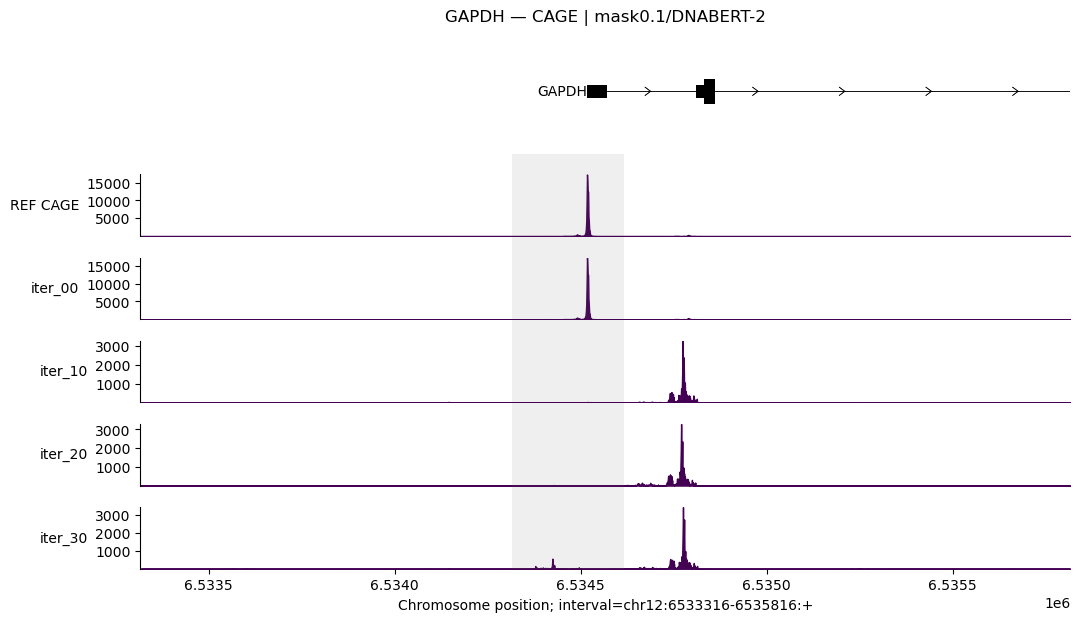

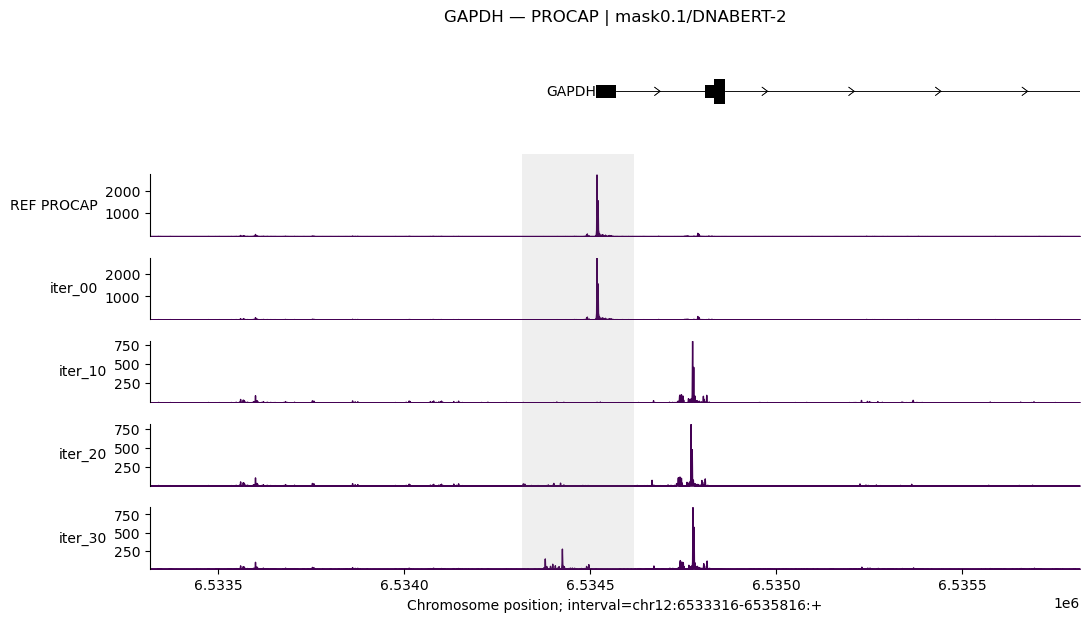

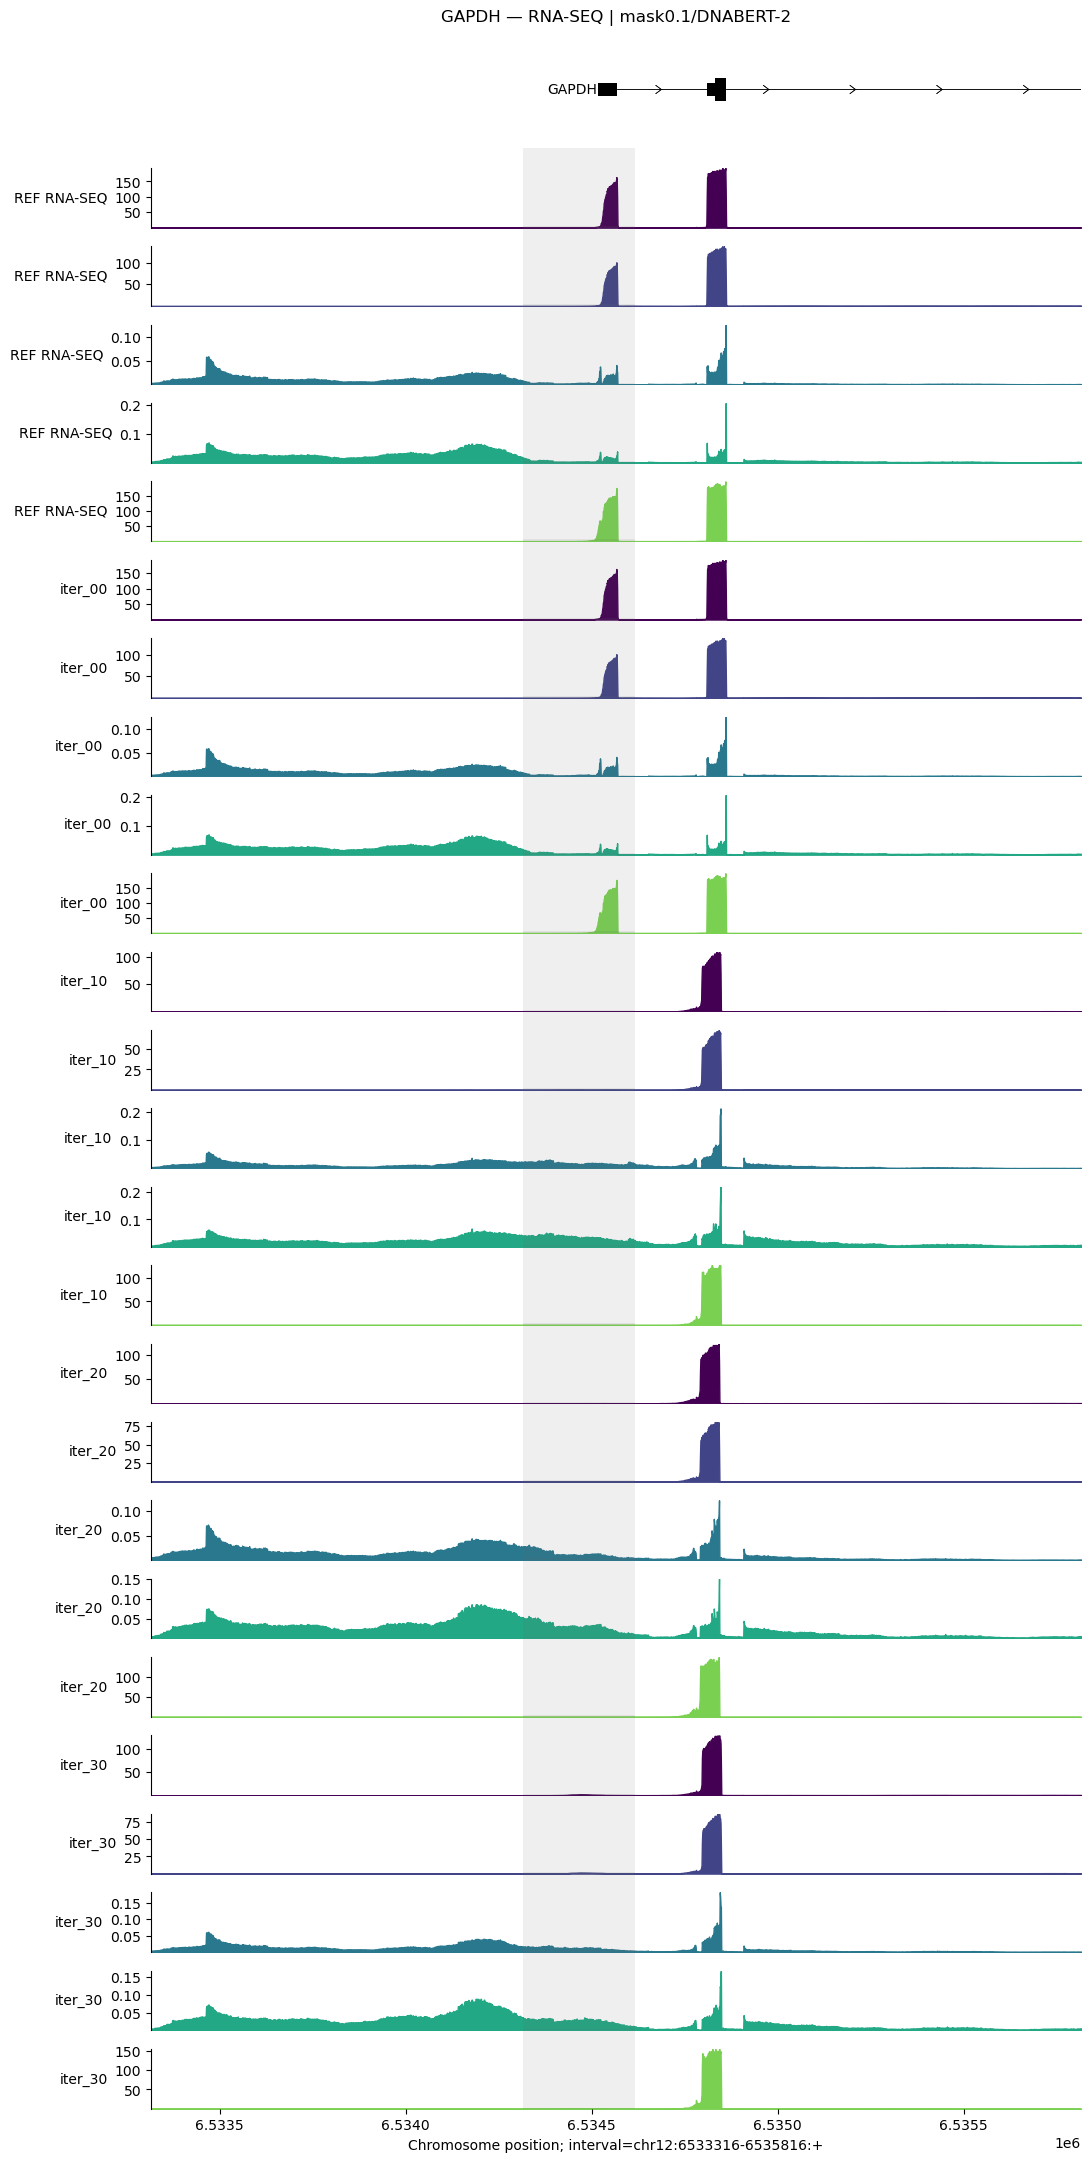

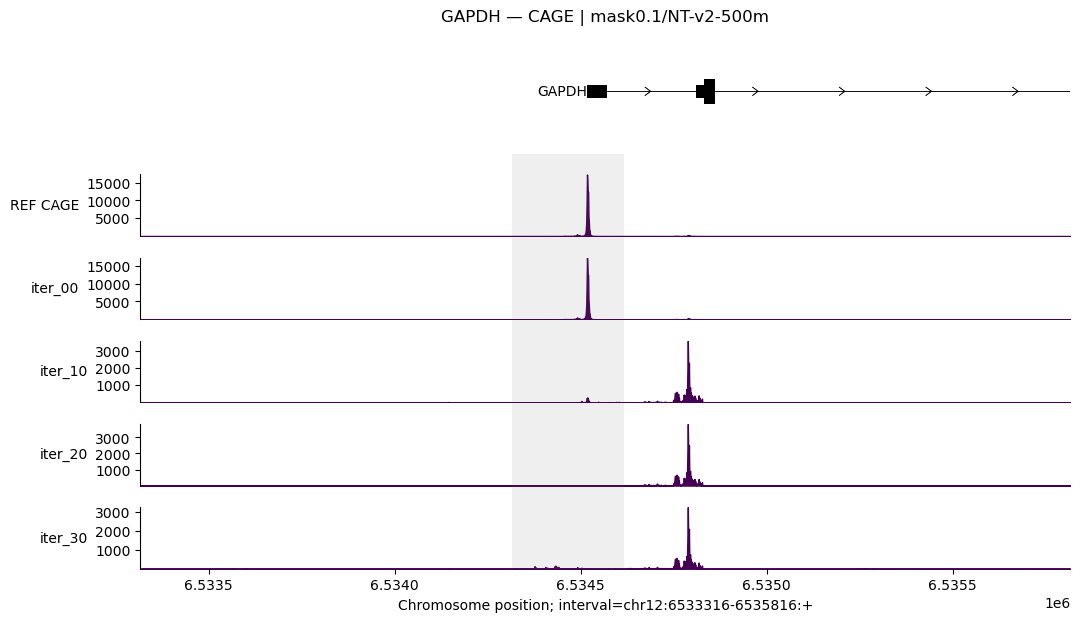

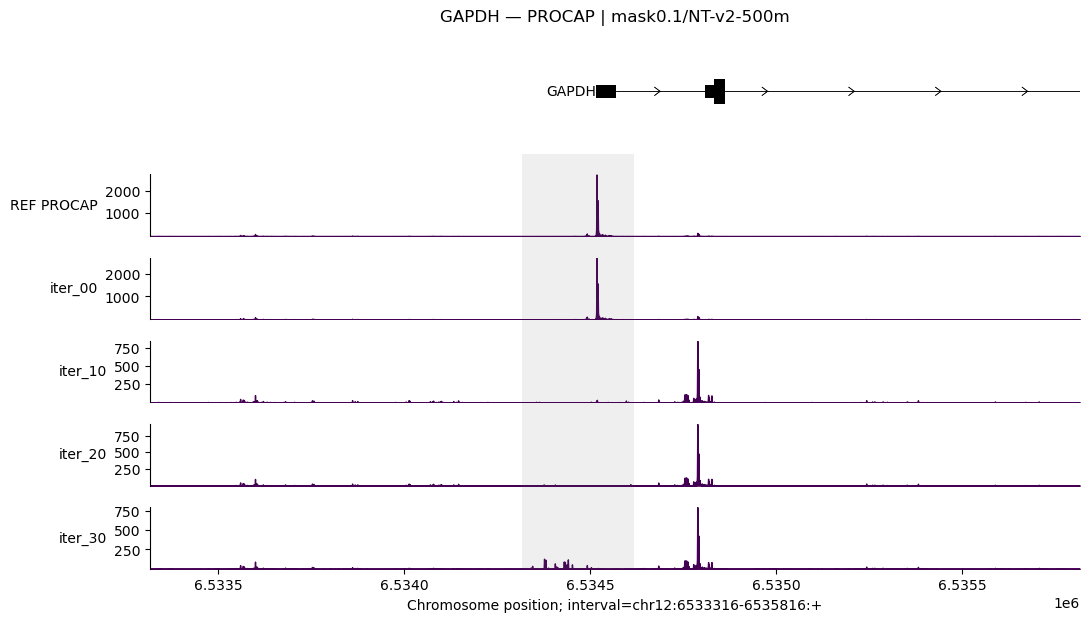

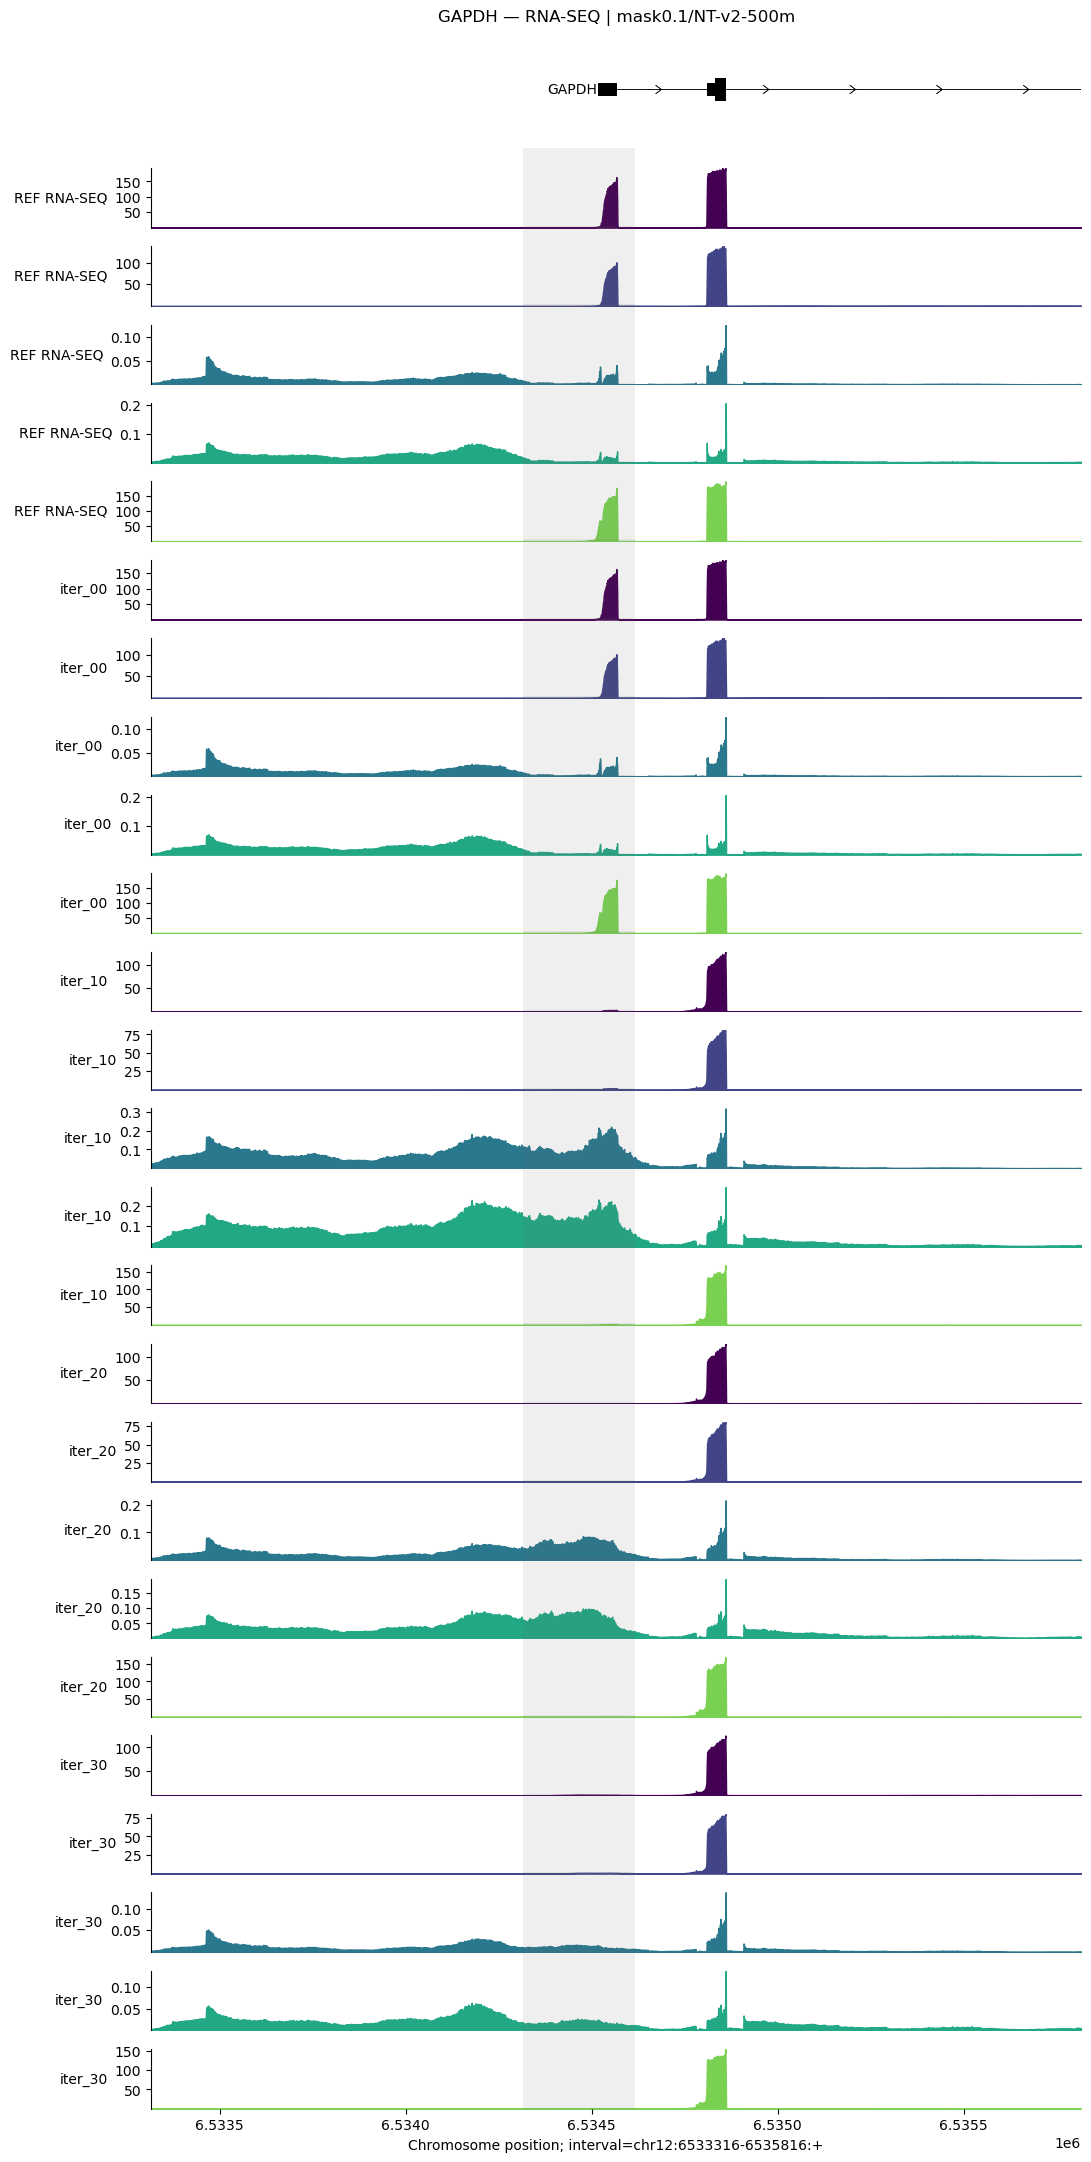

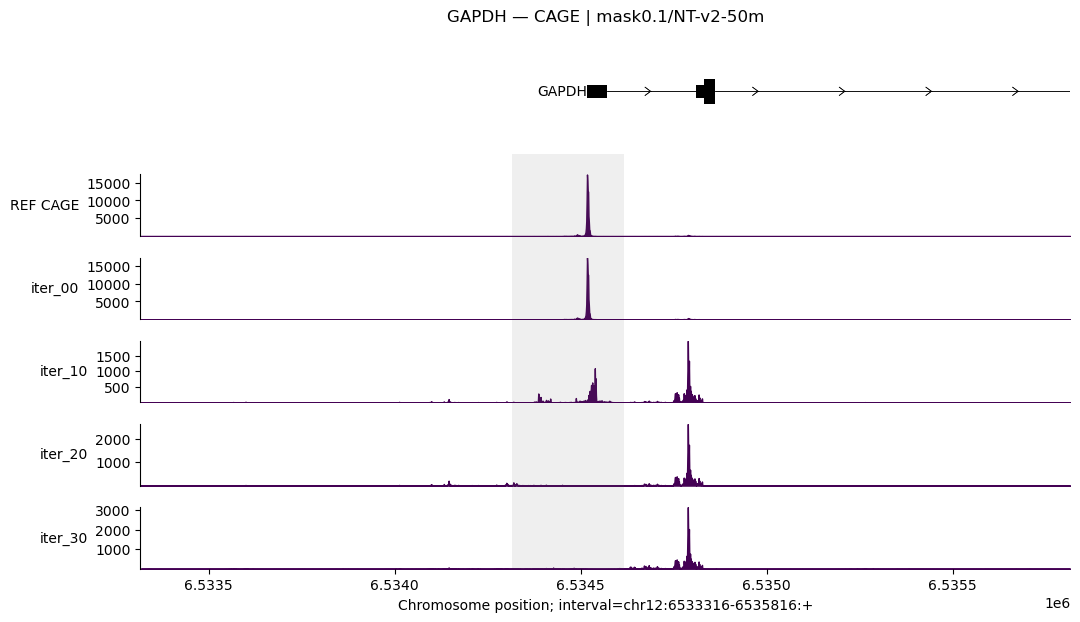

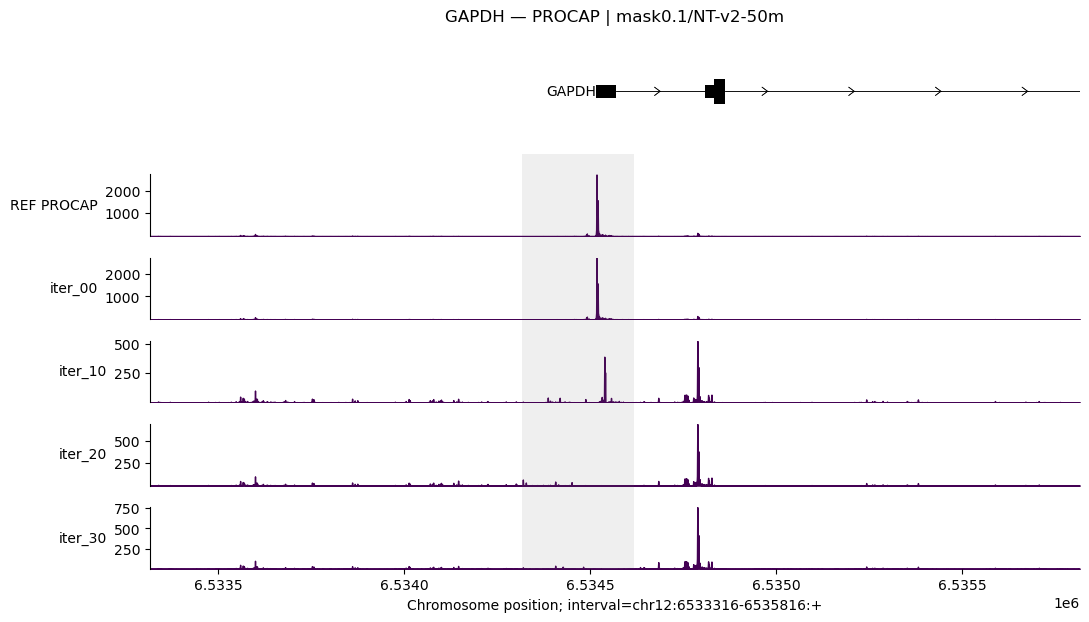

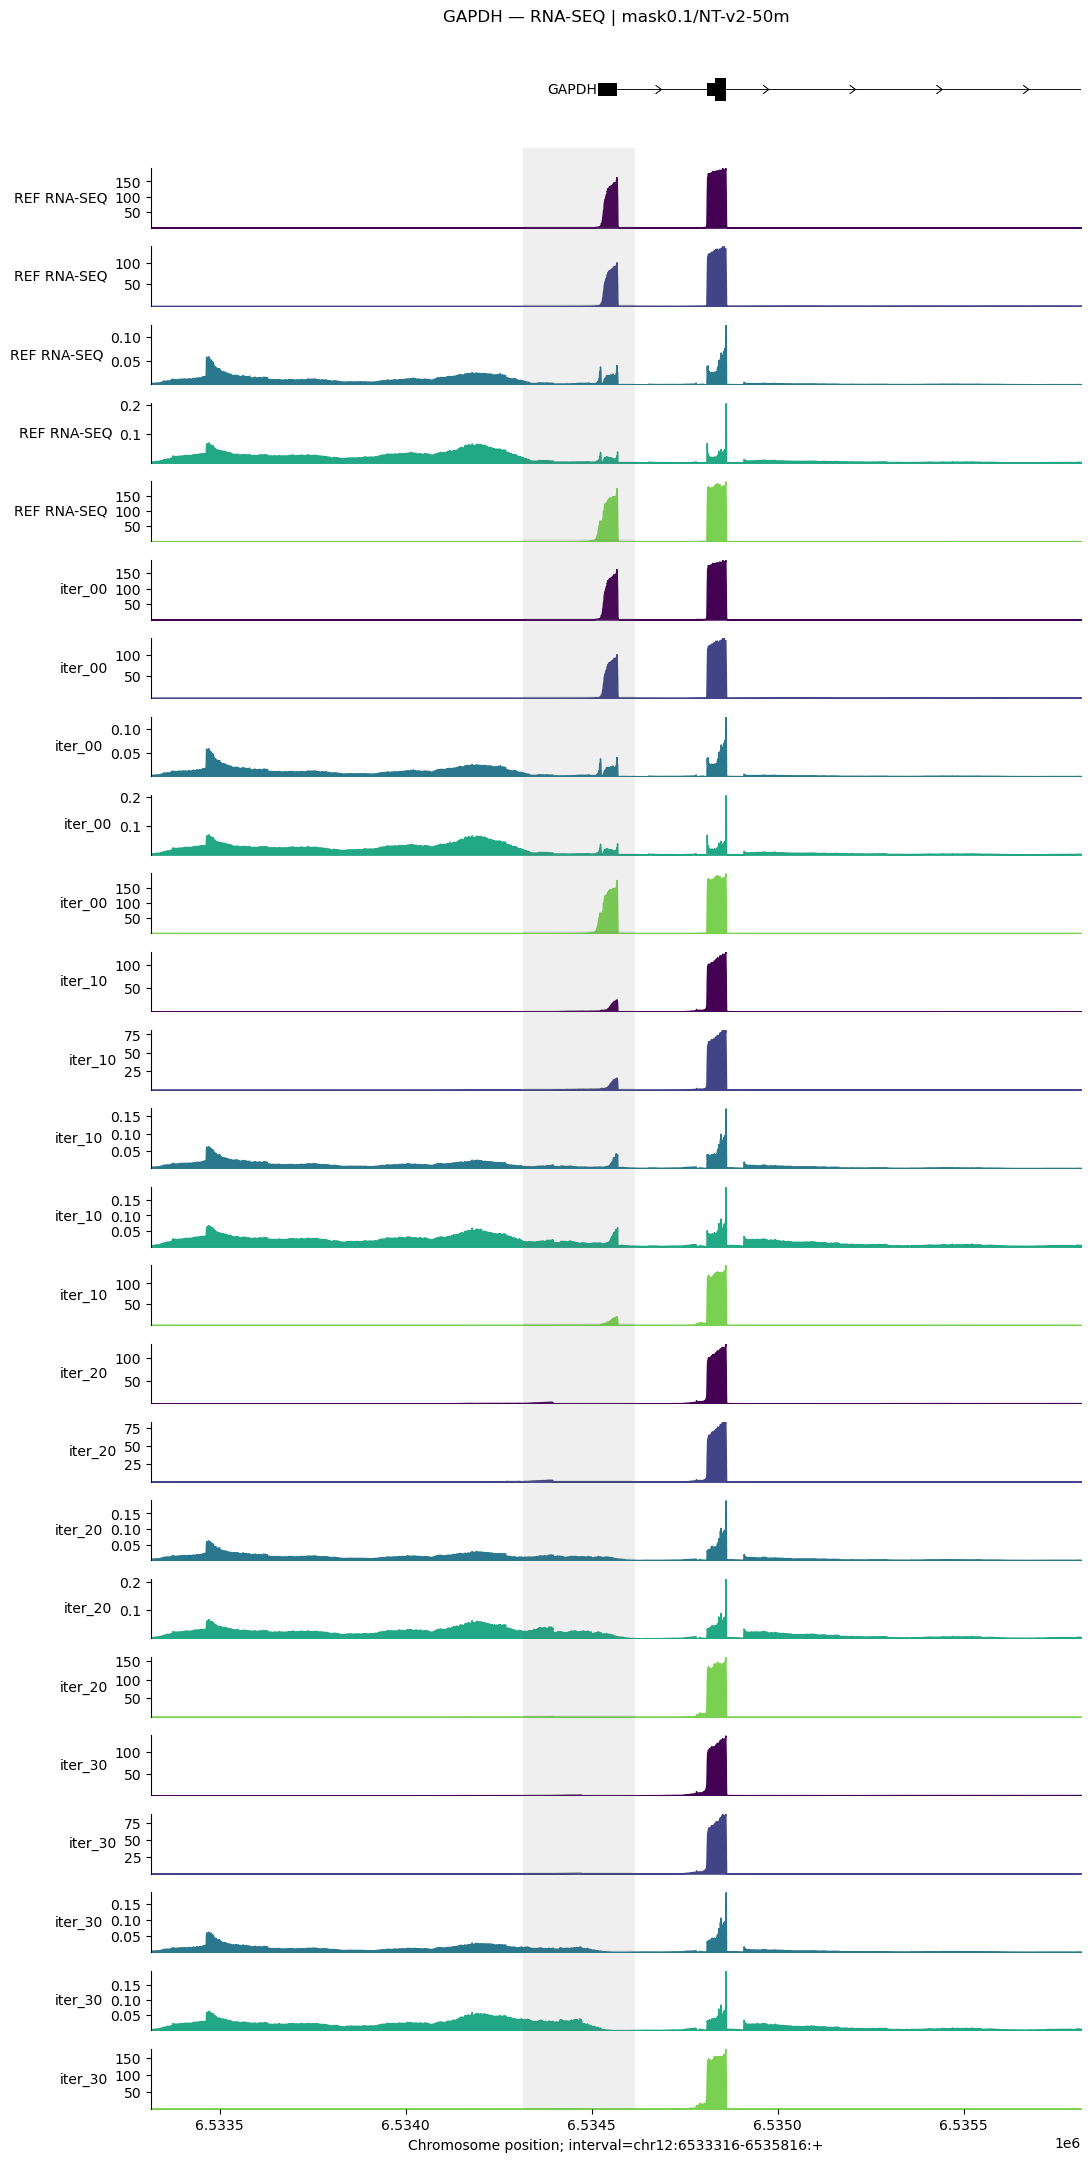

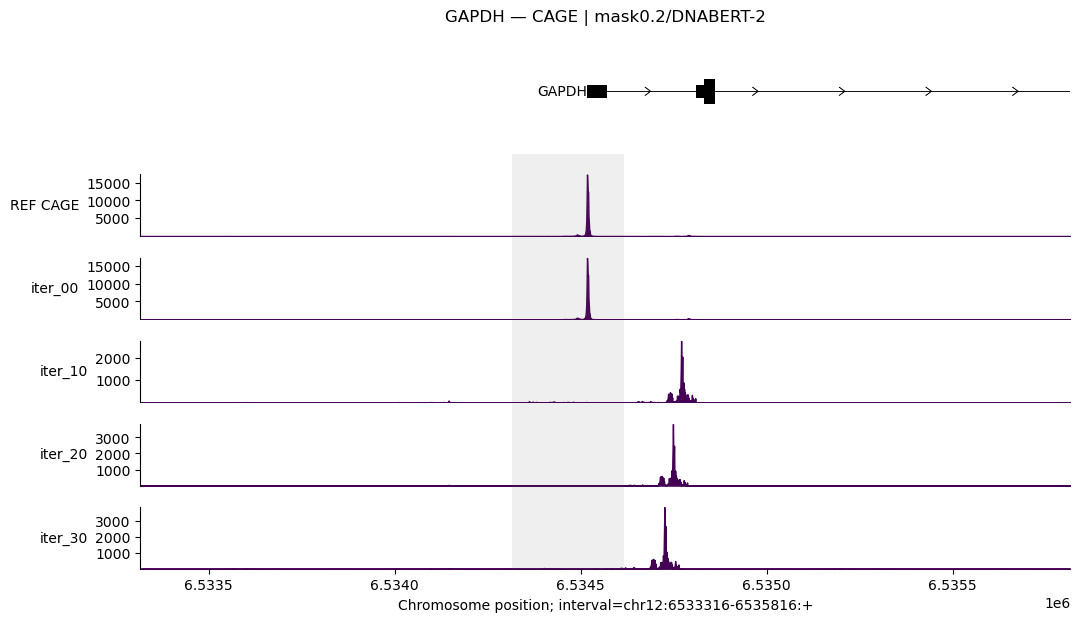

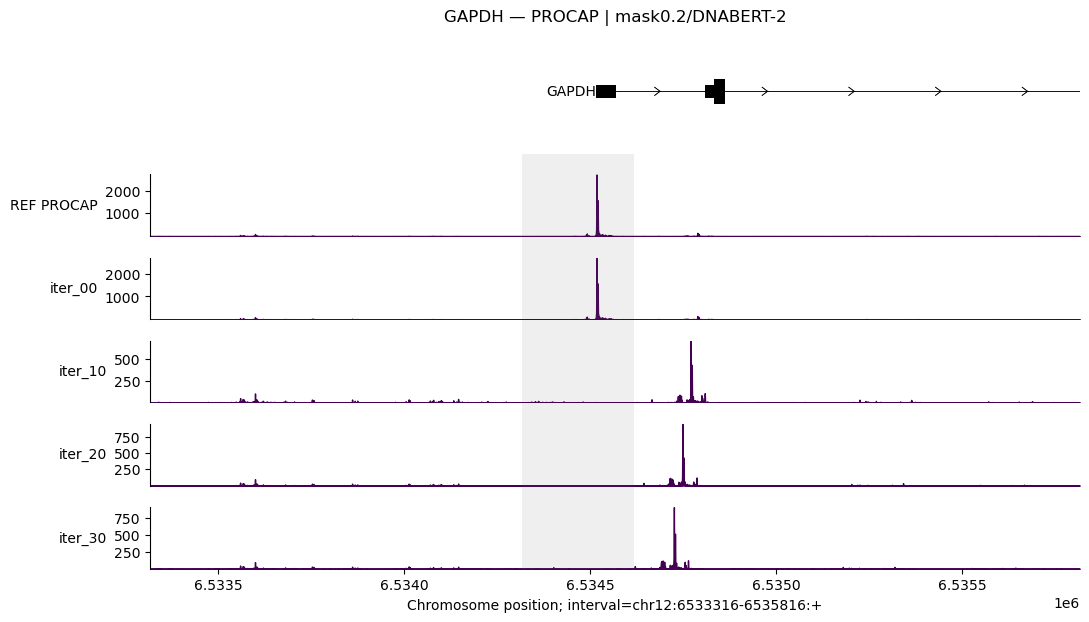

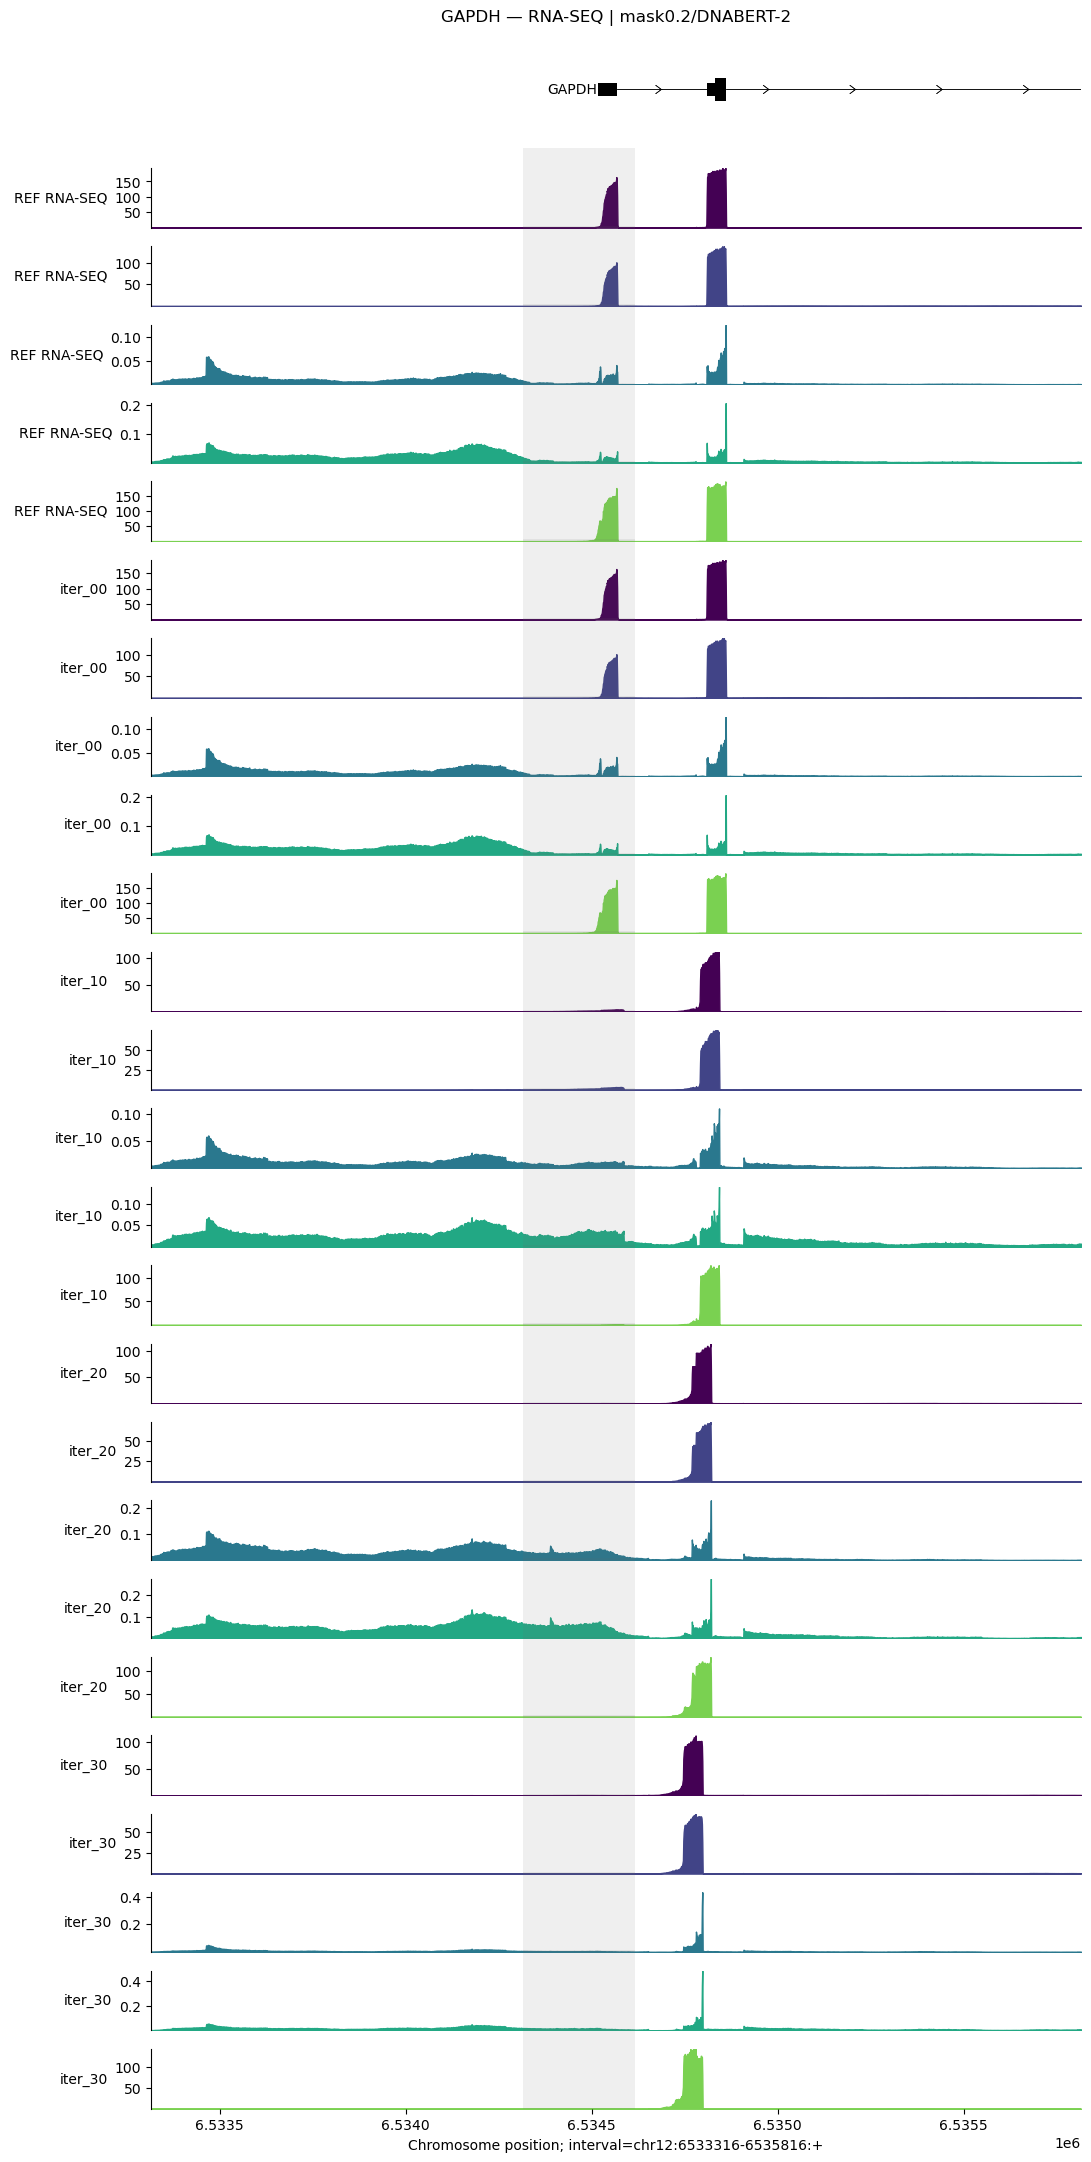

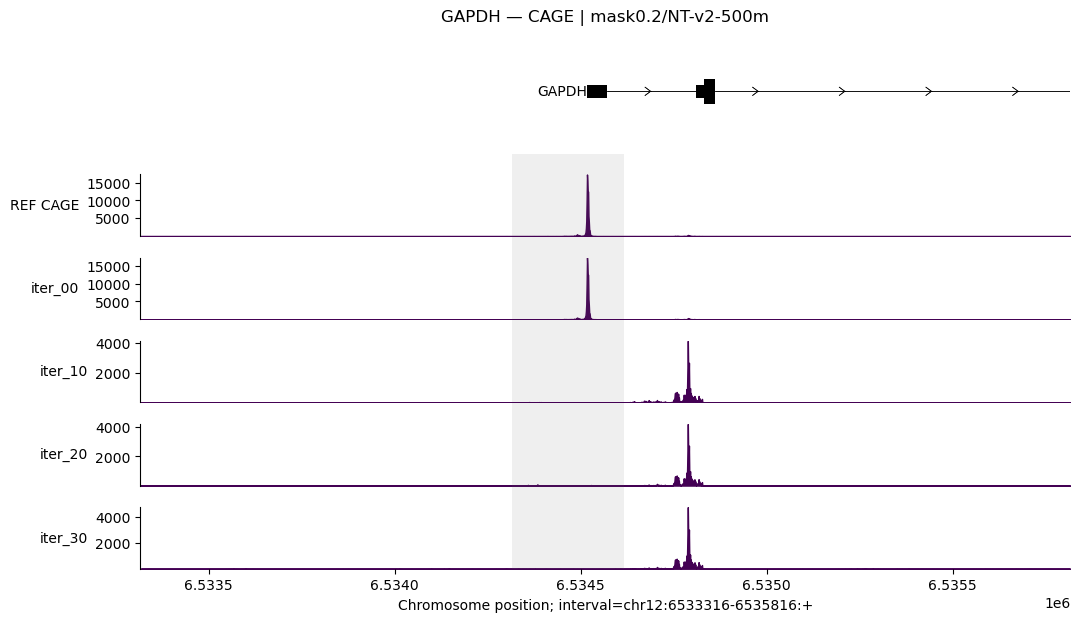

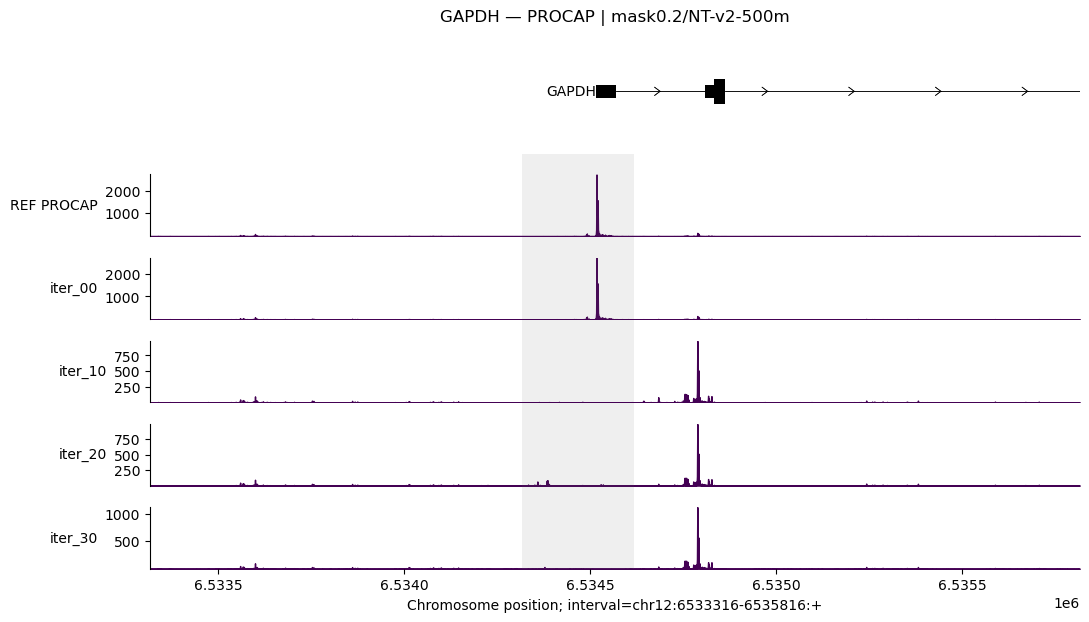

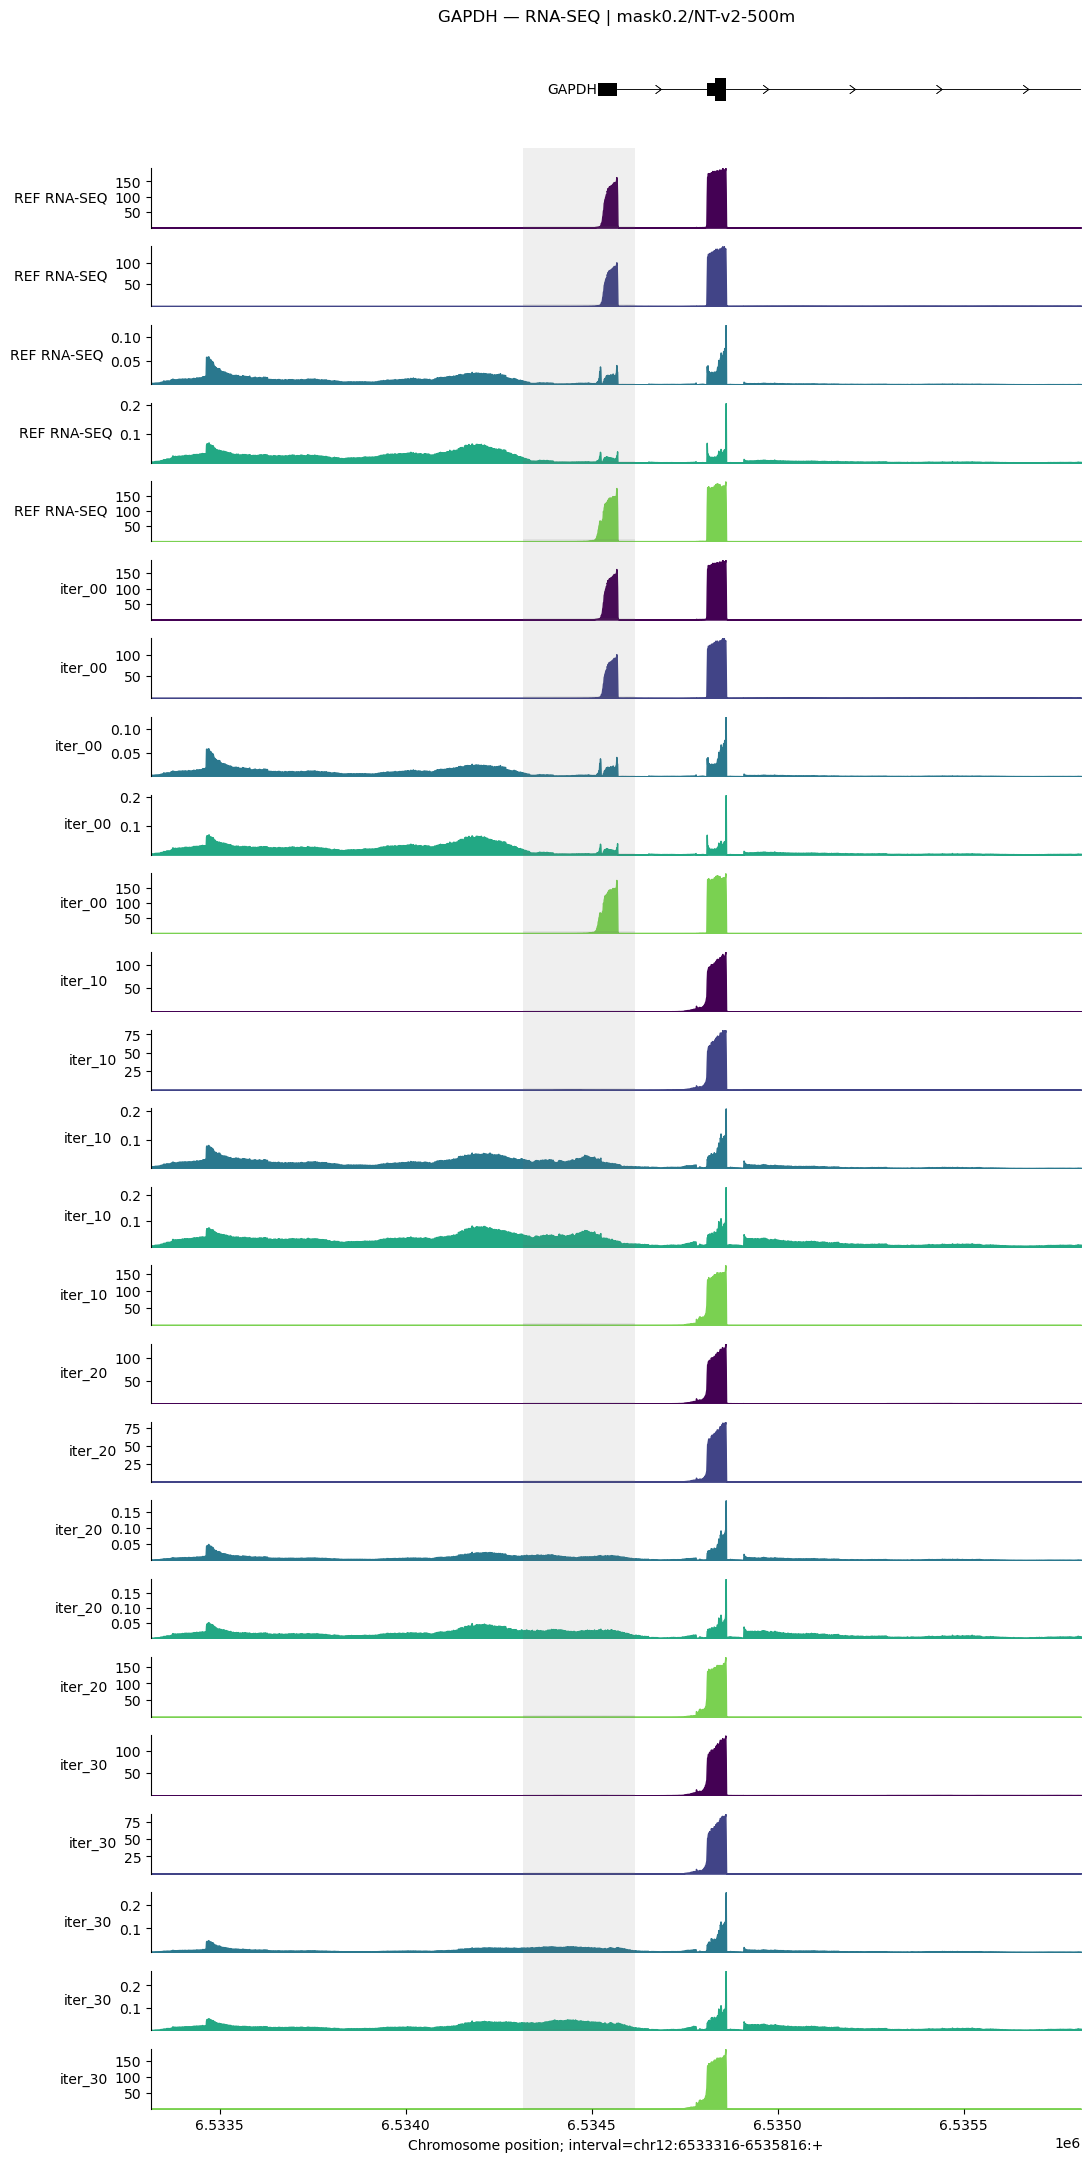

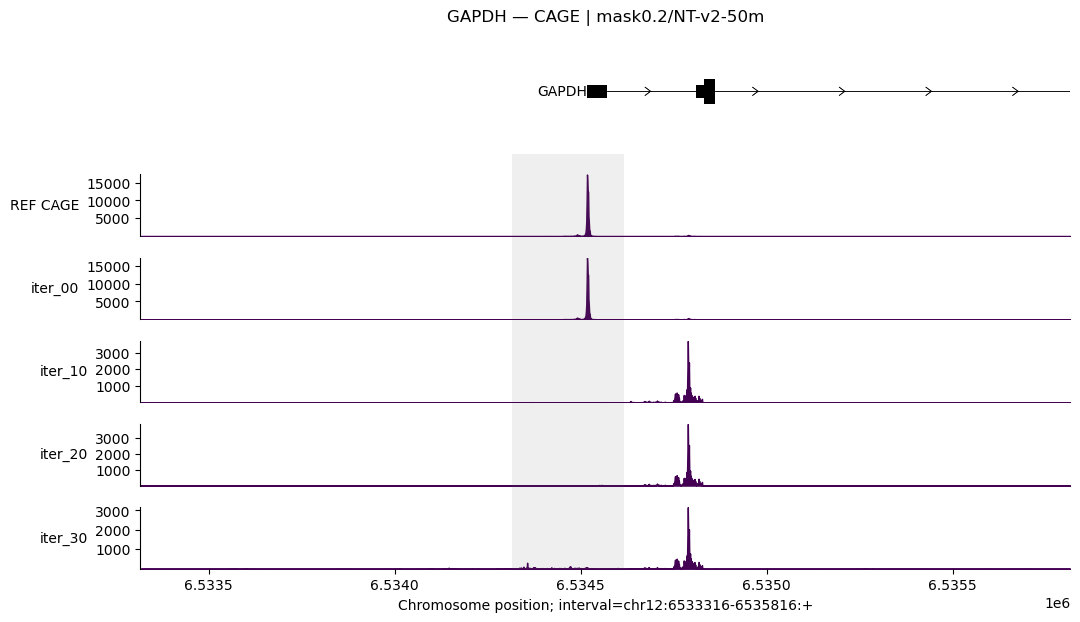

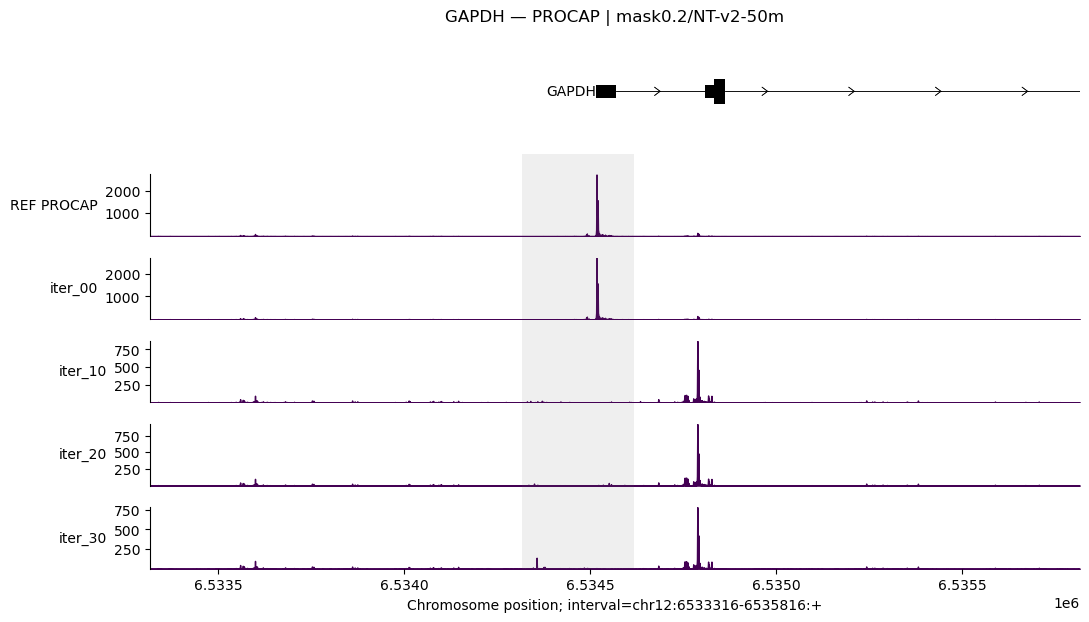

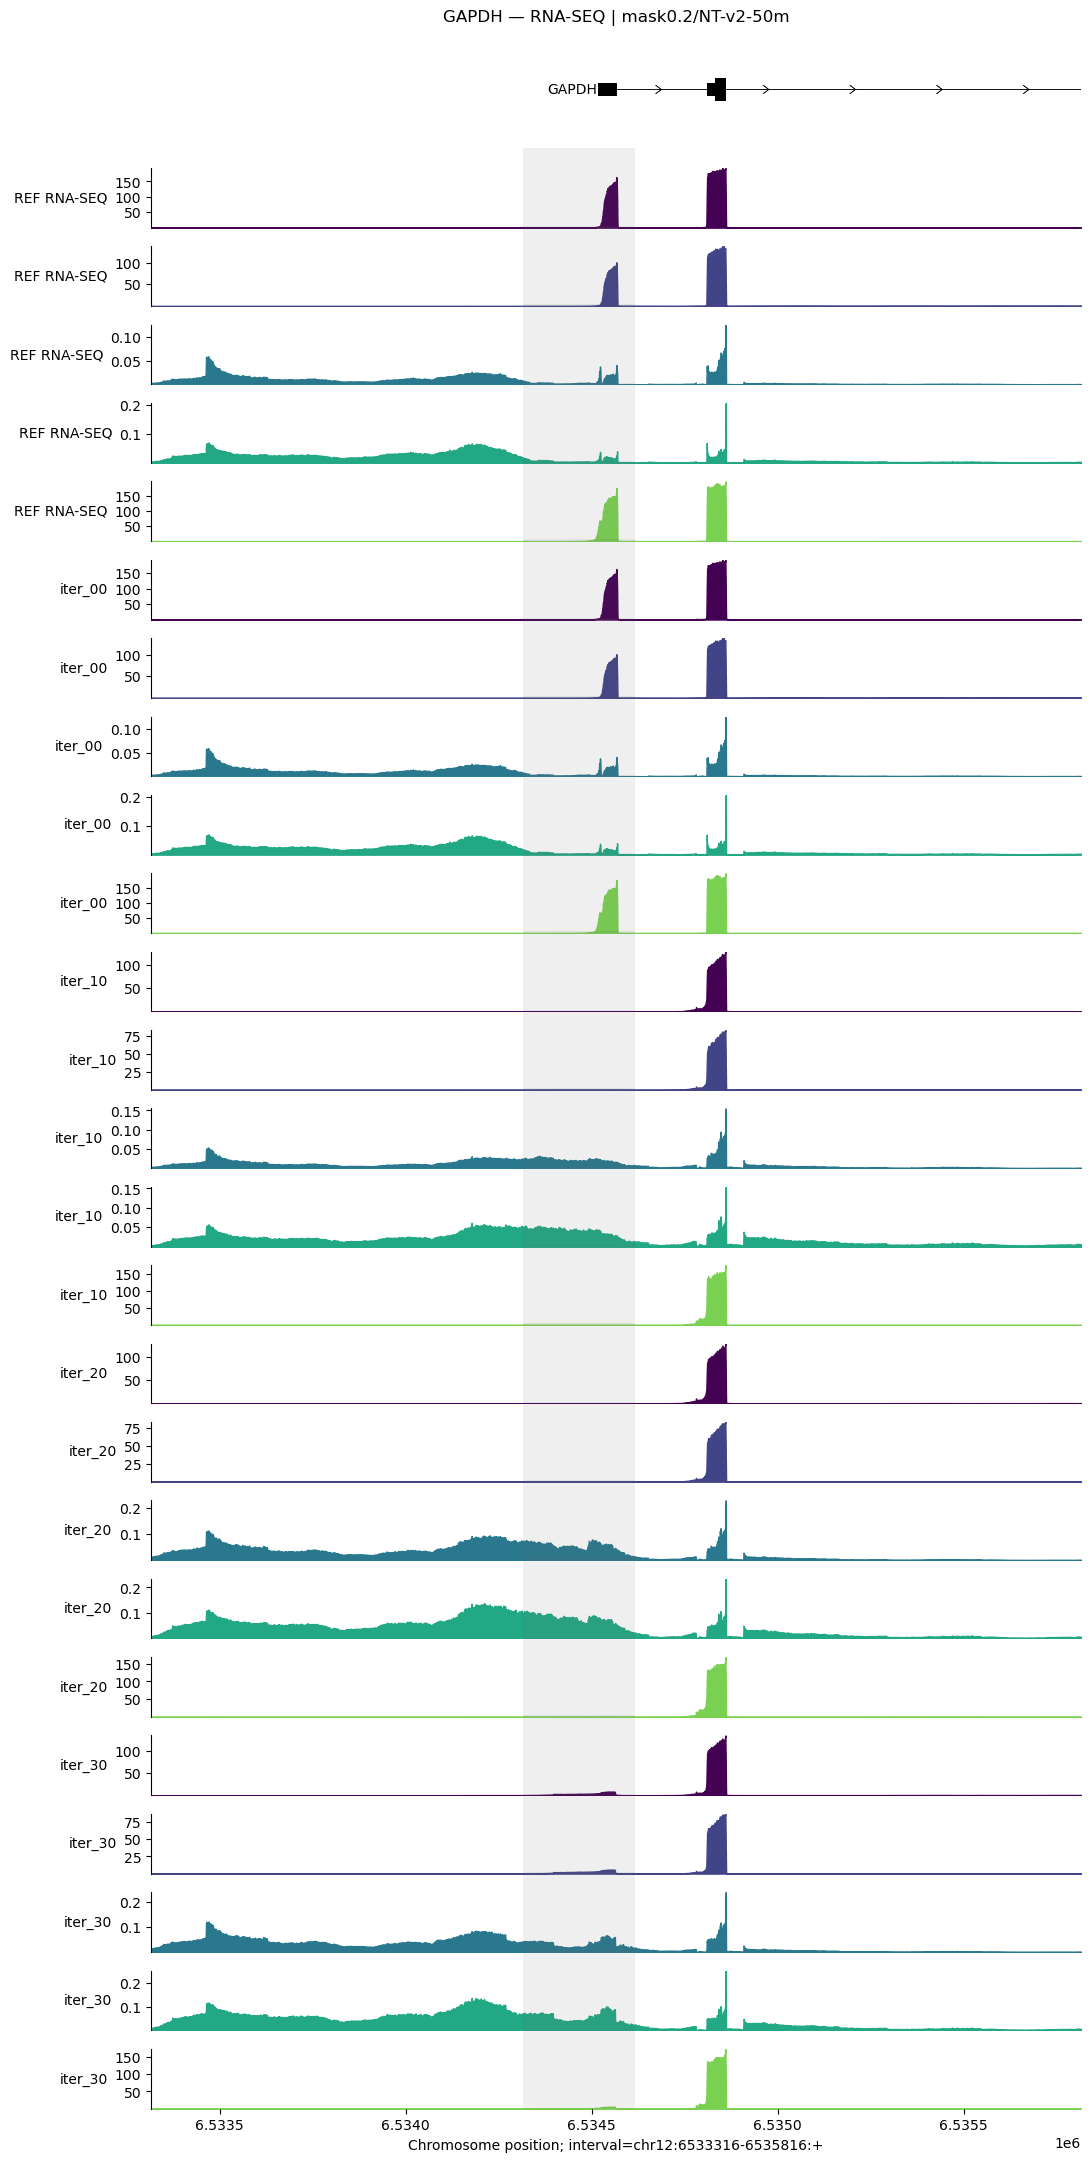

In [18]:
def _filter_by_strand(tracks):
    """Filter tracks to the gene's strand direction (+ → positive, - → negative)."""
    if strand == '+':
        fn = 'filter_to_positive_strand'
    else:
        fn = 'filter_to_negative_strand'
    return getattr(tracks, fn)() if hasattr(tracks, fn) else tracks


def _orient_alt(seq: str, gene_strand: str) -> str:
    """Convert generated sequence to + strand orientation for AlphaGenome Variant."""
    return reverse_complement(seq) if gene_strand == '-' else seq


def _plot_tracks(outputs, eval_iters, track_attr, track_label, title, interval_vis,
                 longest_transcripts, promoter_interval, filter_strand=True):
    """Plot reference and ALT tracks for a given output attribute."""
    ref_tracks = getattr(outputs[0].reference, track_attr)
    if filter_strand:
        ref_tracks = _filter_by_strand(ref_tracks)

    components = [
        pc.TranscriptAnnotation(longest_transcripts),
        pc.Tracks(ref_tracks, filled=True, ylabel_template=f'REF {track_label}'),
    ]
    for i, output in zip(eval_iters, outputs):
        alt_tracks = getattr(output.alternate, track_attr)
        if filter_strand:
            alt_tracks = _filter_by_strand(alt_tracks)
        components.append(
            pc.Tracks(alt_tracks, filled=True, ylabel_template=f'iter_{i:02d}')
        )

    pc.plot(
        components,
        interval=interval_vis.resize(2500),
        annotations=[
            pc.IntervalAnnotation(promoter_interval, colors='dimgrey', alpha=0.1)
        ],
        title=title,
        fig_width=12,
    )


def _peak(output_obj, attr, strand_specific=True, analysis_interval=None):
    """Compute (peak, sum) of a track, optionally sliced to analysis_interval."""
    tracks = getattr(output_obj, attr)
    if strand_specific:
        tracks = _filter_by_strand(tracks)
    if analysis_interval is not None:
        tracks = tracks.slice_by_interval(analysis_interval)
    return float(np.max(tracks.values)), float(np.sum(tracks.values))


# ─────────────────────────────────────────────────────────────────────
# Promoter-region interval (no padding) for heatmap quantification
# ─────────────────────────────────────────────────────────────────────
_promoter_region = genome.Interval(chrom, promoter_start, promoter_end)

# ─────────────────────────────────────────────────────────────────────
# Main evaluation loop
# ─────────────────────────────────────────────────────────────────────
summary_rows = []

for cond in conditions:
    mask_ratio = cond['mask_ratio']
    model_name = cond['model']
    label      = cond['label']
    key        = (mask_ratio, model_name)
    cond_seqs  = sequences[key]

    print(f'\n══════════════════════════════════════')
    print(f'  {label}')
    print(f'══════════════════════════════════════')

    # Build variant list: one variant per evaluation iteration
    valid_iters = [i for i in EVAL_ITERATIONS if f'iter_{i:02d}' in cond_seqs]
    variants = [
        genome.Variant(
            chrom,
            variant_position,
            seq_original,
            _orient_alt(cond_seqs[f'iter_{i:02d}'], strand),
        )
        for i in valid_iters
    ]

    # Predict
    outputs = dna_model_ag.predict_variants(
        intervals=interval,
        variants=variants,
        requested_outputs=requested_outputs,
        ontology_terms=PRELIMINARY_ONTOLOGY_TERMS,
        progress_bar=True,
    )

    # ── CAGE track plots ─────────────────────────────────────────────
    if dna_client.OutputType.CAGE in requested_outputs:
        _plot_tracks(
            outputs, valid_iters, 'cage', 'CAGE',
            f'{GENE_NAME} — CAGE | {label}',
            interval_vis, longest_transcripts, promoter_interval,
        )

    # ── PROCAP track plots ───────────────────────────────────────────
    if dna_client.OutputType.PROCAP in requested_outputs:
        _plot_tracks(
            outputs, valid_iters, 'procap', 'PROCAP',
            f'{GENE_NAME} — PROCAP | {label}',
            interval_vis, longest_transcripts, promoter_interval,
        )

    # ── RNA-SEQ track plots ──────────────────────────────────────────
    if dna_client.OutputType.RNA_SEQ in requested_outputs:
        _plot_tracks(
            outputs, valid_iters, 'rna_seq', 'RNA-SEQ',
            f'{GENE_NAME} — RNA-SEQ | {label}',
            interval_vis, longest_transcripts, promoter_interval,
            filter_strand=False,  # RNA-SEQ is not strand-specific
        )

    # ── Quantitative metrics (full interval + promoter region) ───────
    track_configs = [
        ('cage',    'CAGE',    True),
        ('procap',  'PROCAP',  True),
        ('rna_seq', 'RNA_SEQ', False),
    ]

    for track_attr, track_type, strand_specific in track_configs:
        if not any(ot.name == track_type for ot in requested_outputs):
            continue

        # Full-interval baseline
        ref_peak,       ref_sum       = _peak(outputs[0].reference, track_attr, strand_specific)
        # Promoter-region baseline
        ref_peak_promo, ref_sum_promo = _peak(outputs[0].reference, track_attr, strand_specific,
                                               _promoter_region)

        for idx, i in enumerate(valid_iters):
            alt_peak,       alt_sum       = _peak(outputs[idx].alternate, track_attr, strand_specific)
            alt_peak_promo, alt_sum_promo = _peak(outputs[idx].alternate, track_attr, strand_specific,
                                                   _promoter_region)
            summary_rows.append({
                'condition':   label,
                'mask_ratio':  mask_ratio,
                'model':       model_name,
                'track_type':  track_type,
                'iteration':   i,
                # Full-interval
                'ref_peak':    ref_peak,
                'alt_peak':    alt_peak,
                'ref_sum':     ref_sum,
                'alt_sum':     alt_sum,
                'peak_delta':  alt_peak - ref_peak,
                'peak_ratio':  alt_peak / ref_peak if ref_peak > 0 else float('nan'),
                # Promoter-region only
                'ref_peak_promo':   ref_peak_promo,
                'alt_peak_promo':   alt_peak_promo,
                'ref_sum_promo':    ref_sum_promo,
                'alt_sum_promo':    alt_sum_promo,
                'peak_delta_promo': alt_peak_promo - ref_peak_promo,
                'peak_ratio_promo': alt_peak_promo / ref_peak_promo if ref_peak_promo > 0 else float('nan'),
            })

    del outputs, variants
    gc.collect()
    print(f'  ✓ {label} — done, memory released')

summary_df = pd.DataFrame(summary_rows)
print('\n=== Evaluation complete ===')
print(summary_df.pivot_table(
    index=['condition', 'iteration'],
    columns='track_type',
    values='peak_ratio_promo',
    aggfunc='mean',
).round(4))

### 4-1. CAGE Peak Ratio Heatmap (ALT / REF)

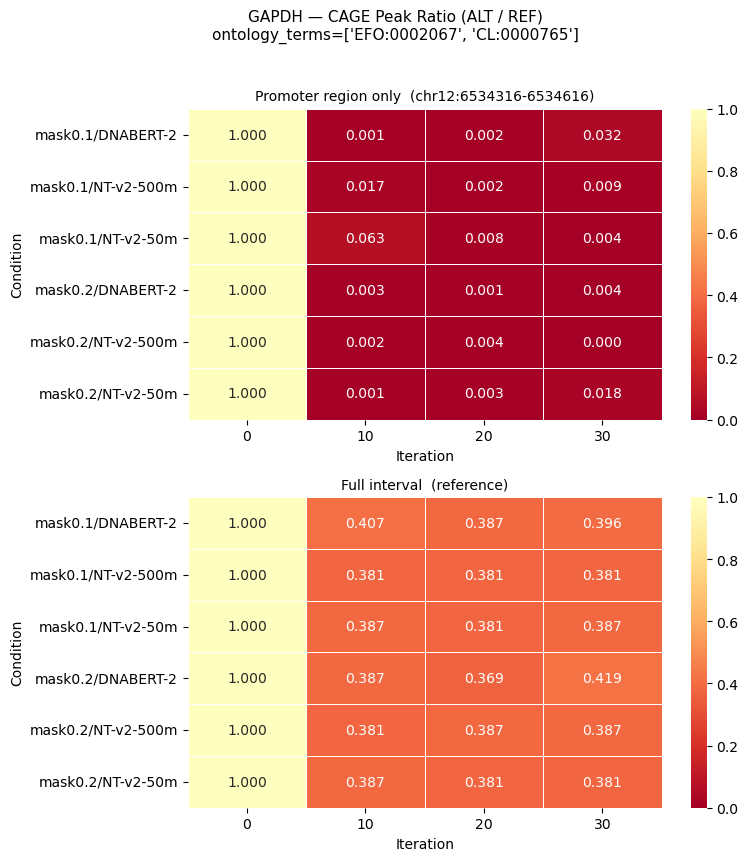

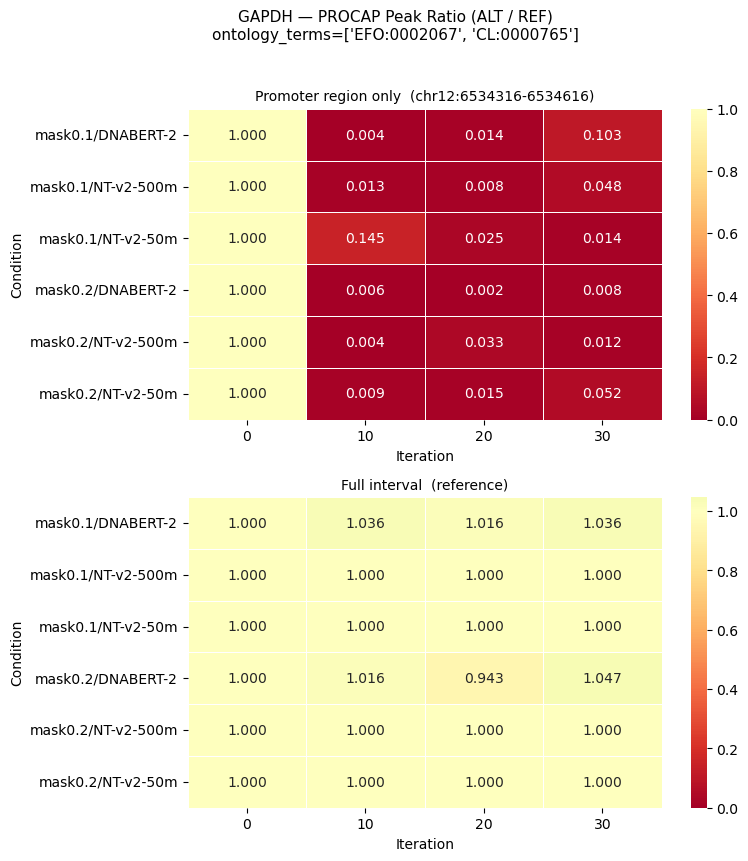

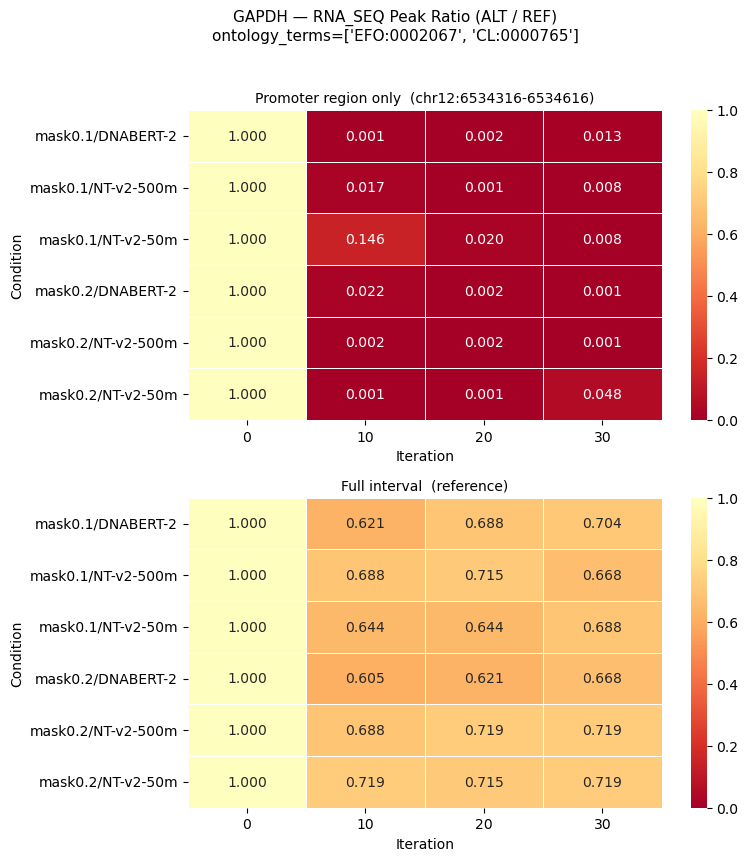

In [19]:
for track_type in ['CAGE', 'PROCAP', 'RNA_SEQ']:
    sub = summary_df[summary_df['track_type'] == track_type]
    if sub.empty:
        continue

    promo_pivot = sub.pivot_table(index='condition', columns='iteration', values='peak_ratio_promo')
    full_pivot  = sub.pivot_table(index='condition', columns='iteration', values='peak_ratio')

    n_rows = max(4, len(promo_pivot) * 0.7)
    fig, (ax_promo, ax_full) = plt.subplots(
        nrows=2, ncols=1,
        figsize=(8, n_rows * 2),
    )

    heatmap_kwargs = dict(annot=True, fmt='.3f', cmap='RdYlGn',
                          center=1.0, vmin=0, linewidths=0.5)

    sns.heatmap(promo_pivot, ax=ax_promo, **heatmap_kwargs)
    ax_promo.set_title(f'Promoter region only  ({chrom}:{promoter_start}-{promoter_end})', fontsize=10)
    ax_promo.set_xlabel('Iteration')
    ax_promo.set_ylabel('Condition')

    sns.heatmap(full_pivot, ax=ax_full, **heatmap_kwargs)
    ax_full.set_title('Full interval  (reference)', fontsize=10)
    ax_full.set_xlabel('Iteration')
    ax_full.set_ylabel('Condition')

    fig.suptitle(f'{GENE_NAME} — {track_type} Peak Ratio (ALT / REF)\n'
                 f'ontology_terms={PRELIMINARY_ONTOLOGY_TERMS}',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

---
## Part 5: CAGE Ontology Scan — Top 10 Cell Types

아래 **설정 셀**에서 확인하고 싶은 `SCAN_ITERATION`을 지정한 후 실행하세요.  
각 조합에서 해당 iteration의 ALT 시퀀스로 **전체 cell ontology를 스캔**하여,  
프로모터 구간의 CAGE peak 기준으로 **reference 대비 ratio가 높은 상위 10개**를 추출합니다.

In [20]:
# ┌──────────────────────────────────────────────────────────────┐
# │  사용자 설정: 스캔할 iteration 번호를 지정하세요              │
# └──────────────────────────────────────────────────────────────┘
SCAN_ITERATION = 30   # ← EVAL_ITERATIONS 중 하나를 입력 (e.g. 0, 10, 20, 30)
TOP_N = 10            # 상위 N개 cell ontology 추출

print(f'Scanning CAGE across ALL cell types at iter_{SCAN_ITERATION:02d}')
print(f'Top {TOP_N} cell ontologies will be extracted per condition')

Scanning CAGE across ALL cell types at iter_30
Top 10 cell ontologies will be extracted per condition


In [21]:
# Analysis window: promoter region ± PROMOTER_PADDING
scan_analysis_interval = genome.Interval(
    chrom,
    promoter_start - PROMOTER_PADDING,
    promoter_end + PROMOTER_PADDING,
)
scan_requested = {dna_client.OutputType.CAGE}
scan_iter_key  = f'iter_{SCAN_ITERATION:02d}'

print(f'Analysis window: {scan_analysis_interval}')
print(f'Scanning {len(conditions)} conditions...')

all_scan_rows = []
top10_per_condition = {}

for cond in conditions:
    mask_ratio = cond['mask_ratio']
    model_name = cond['model']
    label      = cond['label']
    key        = (mask_ratio, model_name)

    alt_seq_raw = sequences[key].get(scan_iter_key)
    if alt_seq_raw is None:
        print(f'  [SKIP] {label}: {scan_iter_key} not found')
        continue

    scan_variant = genome.Variant(
        chrom,
        variant_position,
        seq_original,
        _orient_alt(alt_seq_raw, strand),
    )

    print(f'  Predicting {label} (ontology_terms=None) ...')
    scan_output = dna_model_ag.predict_variant(
        interval=interval,
        variant=scan_variant,
        requested_outputs=scan_requested,
        ontology_terms=None,   # ← ALL cell types
    )

    # Slice to promoter analysis window (strand-aware)
    alt_cage = _filter_by_strand(scan_output.alternate.cage)
    ref_cage = _filter_by_strand(scan_output.reference.cage)
    alt_cage = alt_cage.slice_by_interval(scan_analysis_interval)
    ref_cage = ref_cage.slice_by_interval(scan_analysis_interval)
    metadata = alt_cage.metadata

    rows = []
    for track_idx in range(alt_cage.num_tracks):
        alt_peak = float(np.max(alt_cage.values[:, track_idx]))
        ref_peak = float(np.max(ref_cage.values[:, track_idx]))
        track_meta = metadata.iloc[track_idx]
        rows.append({
            'condition':     label,
            'mask_ratio':    mask_ratio,
            'model':         model_name,
            'track_name':    track_meta.get('name', f'track_{track_idx}'),
            'biosample_name': track_meta.get('biosample_name', 'unknown'),
            'ontology_term': track_meta.get('ontology_term', ''),
            'ref_peak':      ref_peak,
            'alt_peak':      alt_peak,
            'peak_delta':    alt_peak - ref_peak,
            'peak_ratio':    alt_peak / ref_peak if ref_peak > 0 else float('nan'),
        })

    scan_df = pd.DataFrame(rows)
    all_scan_rows.append(scan_df)

    # Top N by ratio
    top_n = (
        scan_df
        .sort_values('peak_ratio', ascending=False)
        .head(TOP_N)
        .reset_index(drop=True)
    )
    top_n.index = range(1, TOP_N + 1)
    top10_per_condition[label] = top_n

    del scan_output, alt_cage, ref_cage, scan_variant
    gc.collect()
    print(f'  ✓ {label} done')

all_scan_df = pd.concat(all_scan_rows, ignore_index=True)
print(f'\nScan complete: {len(all_scan_df)} tracks across {len(all_scan_rows)} conditions')

Analysis window: chr12:6533816-6535116:.
Scanning 6 conditions...
  Predicting mask0.1/DNABERT-2 (ontology_terms=None) ...
  ✓ mask0.1/DNABERT-2 done
  Predicting mask0.1/NT-v2-500m (ontology_terms=None) ...


KeyboardInterrupt: 

### 5-1. Top 10 Cell Ontologies per Condition (CAGE Peak Ratio)

In [ ]:
from IPython.display import display, HTML

for label, top_n in top10_per_condition.items():
    display(HTML(f'<h4>🔬 {label} — iter_{SCAN_ITERATION:02d}: Top {TOP_N} by CAGE ratio</h4>'))
    display(top_n[['biosample_name', 'ontology_term', 'ref_peak', 'alt_peak', 'peak_ratio']]
            .style.format({'ref_peak': '{:.1f}', 'alt_peak': '{:.1f}', 'peak_ratio': '{:.4f}'})
            .background_gradient(subset='peak_ratio', cmap='RdYlGn', vmin=0, vmax=2))

### 5-2. Bar Charts: Top 10 CAGE Ratio per Condition

In [ ]:
n_conditions = len(top10_per_condition)
fig, axes = plt.subplots(
    nrows=n_conditions,
    ncols=1,
    figsize=(12, 4.5 * n_conditions),
    squeeze=False,
)

for ax, (label, top_n) in zip(axes[:, 0], top10_per_condition.items()):
    colors = ['#d73027' if r >= 1.0 else '#4575b4' for r in top_n['peak_ratio']]
    bars = ax.barh(
        top_n['biosample_name'],
        top_n['peak_ratio'],
        color=colors,
        edgecolor='grey',
        linewidth=0.5,
    )
    ax.axvline(x=1.0, color='black', linewidth=1.0, linestyle='--', label='REF baseline')
    ax.set_xlabel('CAGE Peak Ratio (ALT / REF)')
    ax.set_title(f'{label} — iter_{SCAN_ITERATION:02d}: Top {TOP_N} by CAGE Ratio', fontsize=11)
    ax.invert_yaxis()
    ax.legend(fontsize=8)

plt.suptitle(
    f'{GENE_NAME} — CAGE Ontology Scan at iter_{SCAN_ITERATION:02d}',
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.show()

### 5-3. Cross-Condition Summary: Average CAGE Ratio by Cell Type

In [ ]:
# Average ratio across all conditions → which cell types are consistently affected?
avg_ratio = (
    all_scan_df
    .groupby('biosample_name')['peak_ratio']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
)
avg_ratio.columns = ['mean_ratio', 'std_ratio', 'n_conditions']

print(f'=== Top 20 cell types by average CAGE ratio (all conditions at iter_{SCAN_ITERATION:02d}) ===')
display(avg_ratio.head(20).style.format({'mean_ratio': '{:.4f}', 'std_ratio': '{:.4f}'}))

---
## Part 6 (Optional): CHIP-TF Analysis

CAGE 활성 변화의 기전을 파악하기 위해 TF binding site 변화를 확인합니다.  
Part 5의 `SCAN_ITERATION`과 동일한 iteration을 사용합니다.

> ⚠️ **주의**: 이 셀은 독립적으로 실행 가능하지만, API 호출이 추가로 발생합니다.  
> `CHIP_TF_CONDITIONS`를 수정하여 분석할 조합을 제한할 수 있습니다.

In [ ]:
# Optional: CHIP-TF analysis
# Run after Part 5 to understand TF binding changes driving CAGE activity shifts

# Conditions to analyze (default: all; reduce to save API calls)
CHIP_TF_CONDITIONS = conditions  # or e.g. [conditions[0]]

# Top N TF tracks to display
TOP_N_TF = 20

chip_scan_rows = []

for cond in CHIP_TF_CONDITIONS:
    label   = cond['label']
    key     = (cond['mask_ratio'], cond['model'])
    alt_seq_raw = sequences[key].get(scan_iter_key)
    if alt_seq_raw is None:
        print(f'  [SKIP] {label}: {scan_iter_key} not found')
        continue

    chip_variant = genome.Variant(
        chrom,
        variant_position,
        seq_original,
        _orient_alt(alt_seq_raw, strand),
    )

    print(f'  CHIP-TF: {label} (iter_{SCAN_ITERATION:02d}) ...')
    chip_output = dna_model_ag.predict_variant(
        interval=interval,
        variant=chip_variant,
        requested_outputs={dna_client.OutputType.CHIP_CHIP_TF},
        ontology_terms=None,
    )

    # Slice to promoter window
    alt_chip = chip_output.alternate.chip_chip_tf.slice_by_interval(scan_analysis_interval)
    ref_chip = chip_output.reference.chip_chip_tf.slice_by_interval(scan_analysis_interval)
    chip_meta = alt_chip.metadata

    for track_idx in range(alt_chip.num_tracks):
        alt_peak = float(np.max(alt_chip.values[:, track_idx]))
        ref_peak = float(np.max(ref_chip.values[:, track_idx]))
        track_meta = chip_meta.iloc[track_idx]
        chip_scan_rows.append({
            'condition':   label,
            'tf_name':     track_meta.get('tf_name', track_meta.get('name', f'tf_{track_idx}')),
            'biosample_name': track_meta.get('biosample_name', 'unknown'),
            'ref_peak':    ref_peak,
            'alt_peak':    alt_peak,
            'peak_delta':  alt_peak - ref_peak,
            'peak_ratio':  alt_peak / ref_peak if ref_peak > 0 else float('nan'),
        })

    del chip_output, alt_chip, ref_chip, chip_variant
    gc.collect()
    print(f'  ✓ {label} CHIP-TF done')

chip_df = pd.DataFrame(chip_scan_rows)

# Top TFs gained (ratio > 1) and lost (ratio < 1) per condition
for cond_label in chip_df['condition'].unique():
    sub = chip_df[chip_df['condition'] == cond_label]
    top_gained = sub.sort_values('peak_ratio', ascending=False).head(TOP_N_TF)
    top_lost   = sub.sort_values('peak_ratio', ascending=True).head(TOP_N_TF)
    display(HTML(f'<h4>{cond_label} — iter_{SCAN_ITERATION:02d}: TFs GAINED (ratio ↑)</h4>'))
    display(top_gained[['tf_name', 'biosample_name', 'ref_peak', 'alt_peak', 'peak_ratio']]
            .reset_index(drop=True)
            .style.format({'ref_peak': '{:.2f}', 'alt_peak': '{:.2f}', 'peak_ratio': '{:.3f}'}))
    display(HTML(f'<h4>{cond_label} — iter_{SCAN_ITERATION:02d}: TFs LOST (ratio ↓)</h4>'))
    display(top_lost[['tf_name', 'biosample_name', 'ref_peak', 'alt_peak', 'peak_ratio']]
            .reset_index(drop=True)
            .style.format({'ref_peak': '{:.2f}', 'alt_peak': '{:.2f}', 'peak_ratio': '{:.3f}'}))